In [1]:
#import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import seaborn as sns
import pickle


from matplotlib.colors import ListedColormap

import warnings


warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", RuntimeWarning)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"squidpy\.pl\._spatial_utils"
)



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "figures"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# dotplot of expression

In [3]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata_5k=sc.read_h5ad(PATH2)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST

 
 

In [4]:
CATEGORY="lvl5_annotation"
NICHE_COLUMN   = "niche19"
NICHE_COL=NICHE_COLUMN

In [5]:
# sc.pp.normalize_total(adata_5k, target_sum=1e4)
# sc.pp.log1p(adata_5k)

In [6]:
# cell_types = adata_5k[adata_5k.obs[NICHE_COLUMN]=="Sebaceous_immune"].obs.lvl5_annotation.unique()
# cell_types
 

In [7]:
# na_counts = (
#     adata_5k.obs
#     .groupby("sample_id")[NICHE_COLUMN]
#     .apply(lambda x: x.isna().sum())
#     .sort_values(ascending=False)
# )

# na_counts.head(5)


           

# e9f

In [8]:
adata_5k_i = adata_5k[(adata_5k.obs["niche19"].str.startswith("Epidermis_APC"))]
                     

    
    
    
NICHE="Epidermis_APChi"
valid_samples = adata_5k_i.obs["sample_id"].value_counts()
valid_samples = valid_samples[valid_samples > 10].index

adata_5k_i = adata_5k_i[adata_5k_i.obs["sample_id"].isin(valid_samples)]
adata_5k_i.obs.sample_id.value_counts()

sample_id
BK22_Lesional Baseline          354
BK23_Lesional Baseline          135
3D_BK22_Lesional_baseline-D2     74
3D_BK22_Lesional_baseline-B2     21
BK18_Lesional Baseline           19
BK24_Non-lesional Baseline       17
BK23_Non-lesional Baseline       15
Name: count, dtype: int64

In [9]:
adata_5k_i.obs["niche19"].value_counts()

niche19
Epidermis_APChi    635
Name: count, dtype: int64

In [10]:
# """
# plot genes
# """
# for i, DONOR_ID in enumerate(['BK22_Lesional Baseline',
#  'BK23_Lesional Baseline',
#  '3D_BK22_Lesional_baseline-D2',
#  #'BK25_Week 12', 
#                               #'BK21_Week 12' 
#                              ]  ):
#     adata_i = adata_5k_i[adata_5k_i.obs["sample_id"] == DONOR_ID]
#     print(adata_i.shape)
#     #print(i+1, "/", len(samples_to_keep))
#     #STATUS = adata_i.obs["Site_status"].unique()[0]
#    # TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
#    # DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
#     #INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
#         CELL_COUNT = adata_ii.shape[0]
#         print("Cell count for slide: ", CELL_COUNT)
#         print()
#         if CELL_COUNT > 10:
#            # SEB_SAMPLES.append(DONOR_ID)
#             print(DONOR_ID)
#             sq.pl.spatial_scatter(
#                 adata_i,
#                 library_id="spatial",
#                 shape=None,
#                 color=['IL15', "CCL19", 'PNPLA3',],
#                 cmap="Reds", #=palette,
#                 size=1,
#                 vmax=3,
#                 title=['', '',''],
#                 #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
#                 edgecolor='black',
#                 linewidth=0.01,
#                 legend_loc=None,
#                 #save=f"sebimmune_nicheonly_{DONOR_ID}.pdf"
#                 # ax=ax,
#                 # legend_loc="on data"
#                 #save="supp9d_expression.pdf"

#             )
            
# #sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


In [11]:
import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

with open(file_path, 'rb') as file:
    colors = pickle.load(file)

# Fig 4c 

In [12]:
# ['BK22_Lesional Baseline',
#  'BK23_Lesional Baseline',
#  '3D_BK22_Lesional_baseline-D2',
#  #'BK25_Week 12', 
#                               #'BK21_Week 12' 
#                              ] 
SAMPLES=list(adata_5k_i.obs.sample_id.unique())

0
Cell count for slide:  354

BK22_Lesional Baseline
1
Cell count for slide:  15

BK23_Non-lesional Baseline


/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


2
Cell count for slide:  135

BK23_Lesional Baseline
3
Cell count for slide:  19

BK18_Lesional Baseline
4
Cell count for slide:  17



/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


BK24_Non-lesional Baseline
5
Cell count for slide:  21

3D_BK22_Lesional_baseline-B2
6
Cell count for slide:  74



/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1277285088.py:37: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


3D_BK22_Lesional_baseline-D2


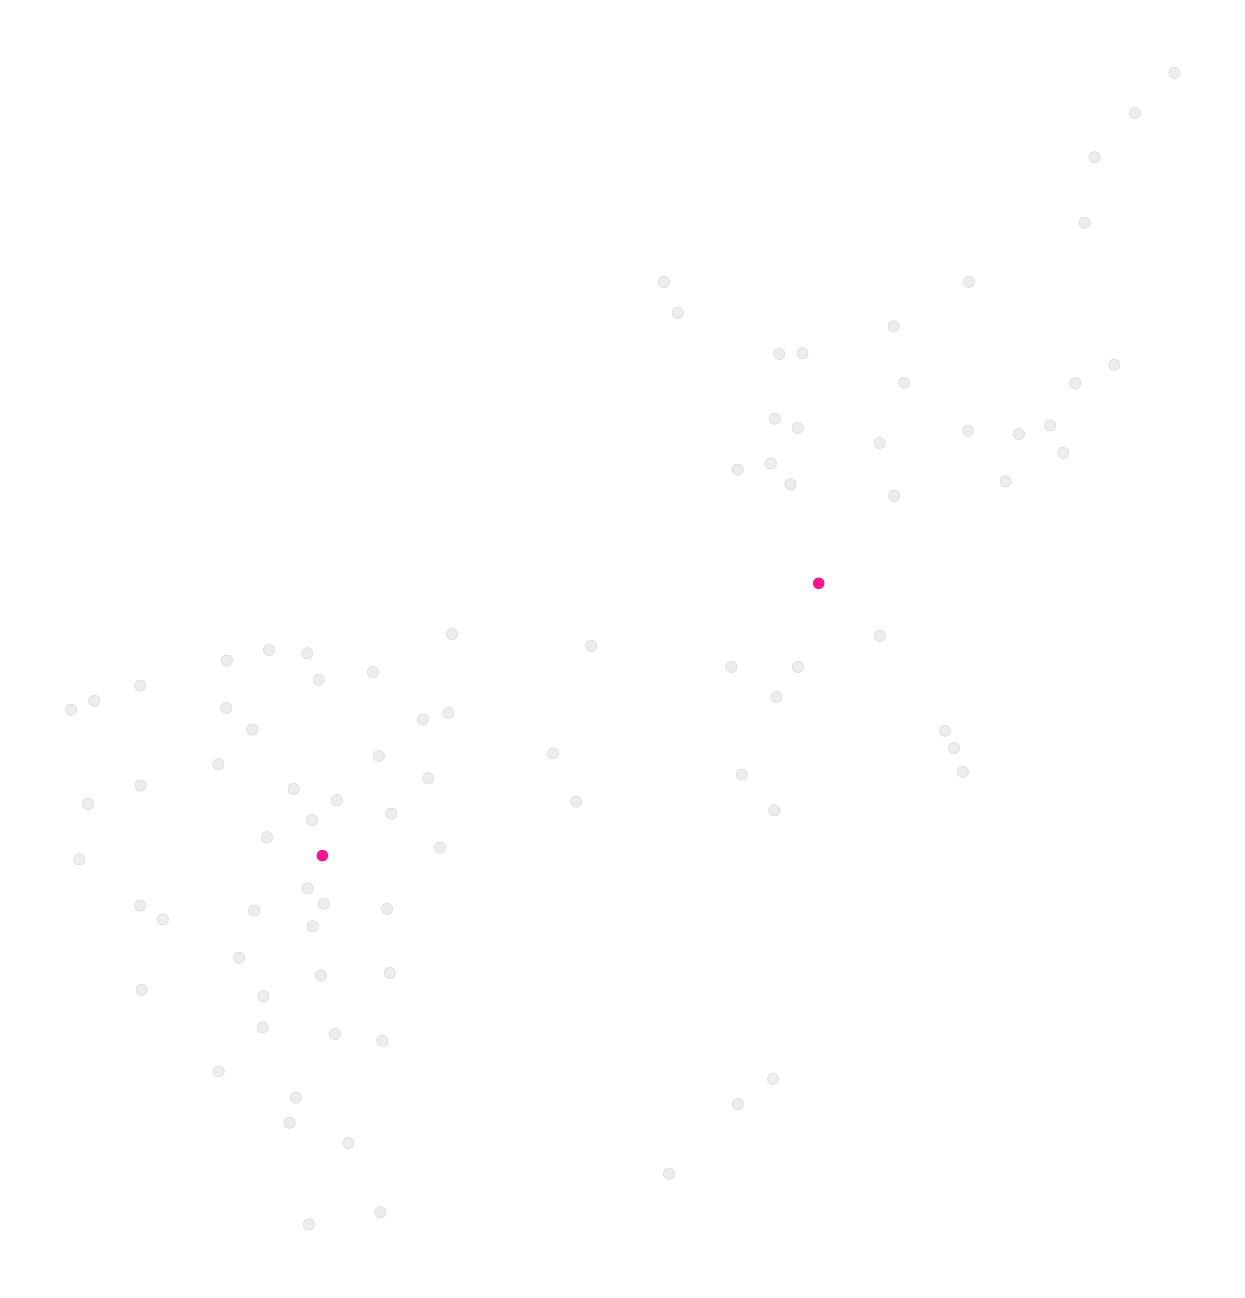

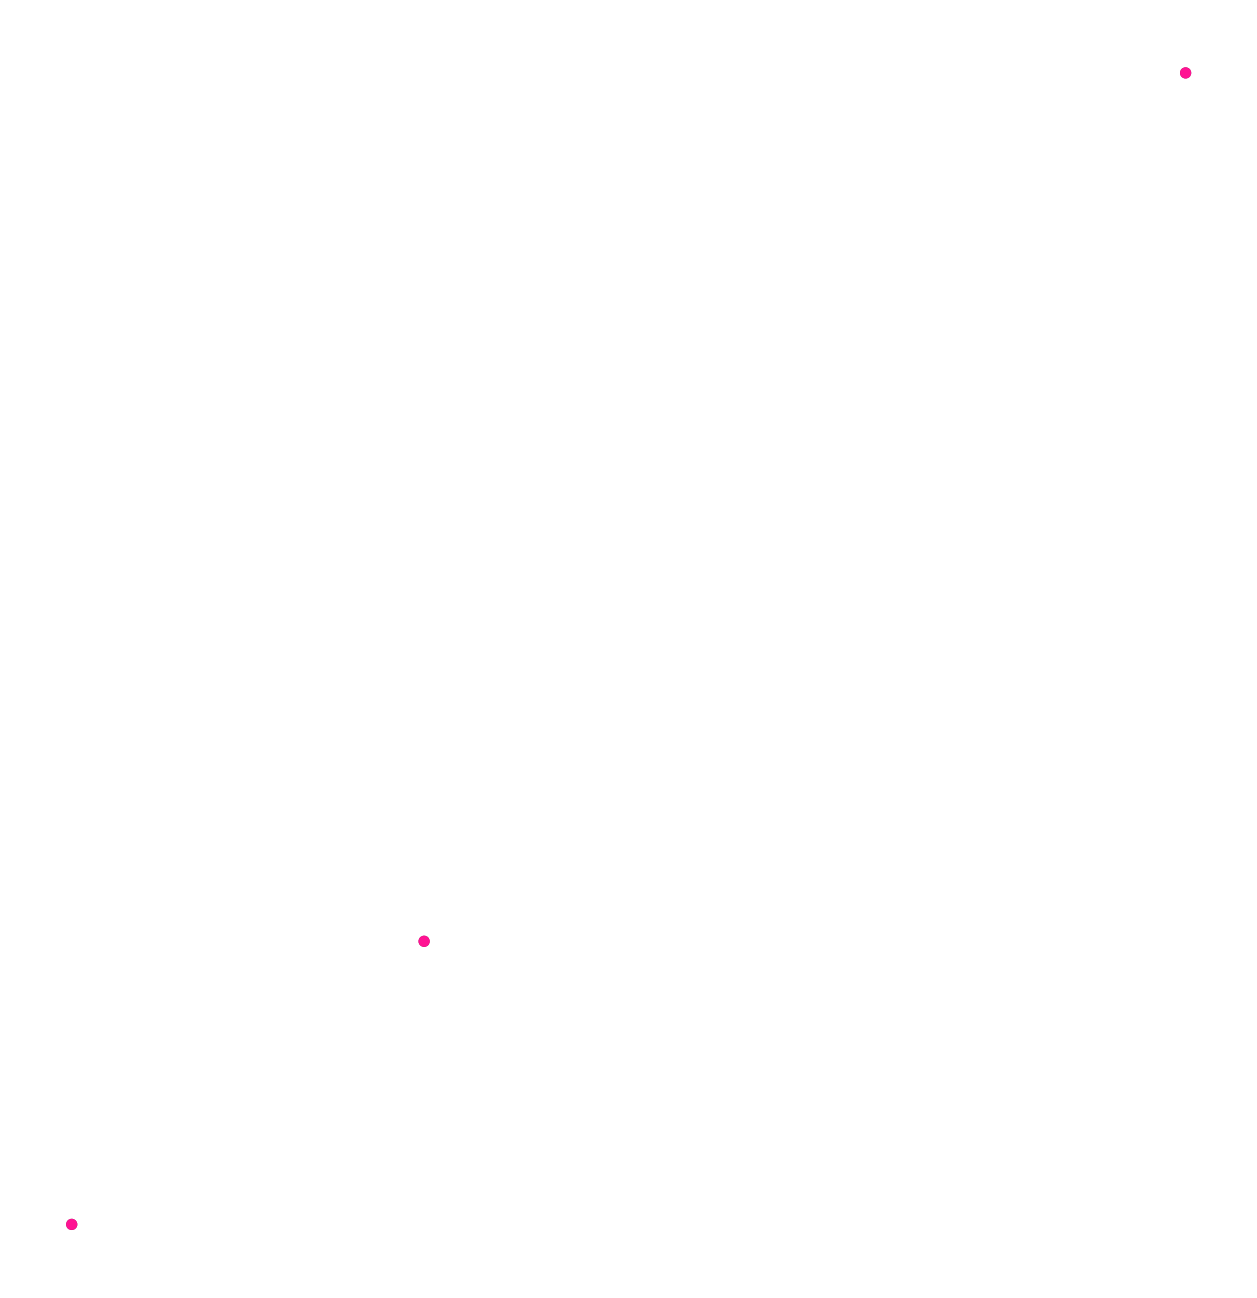

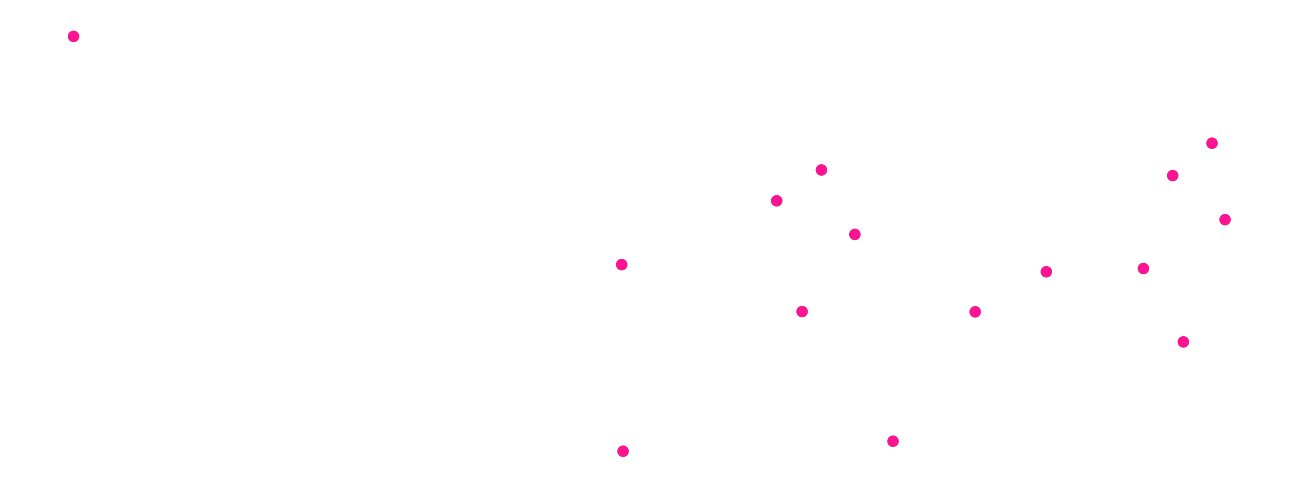

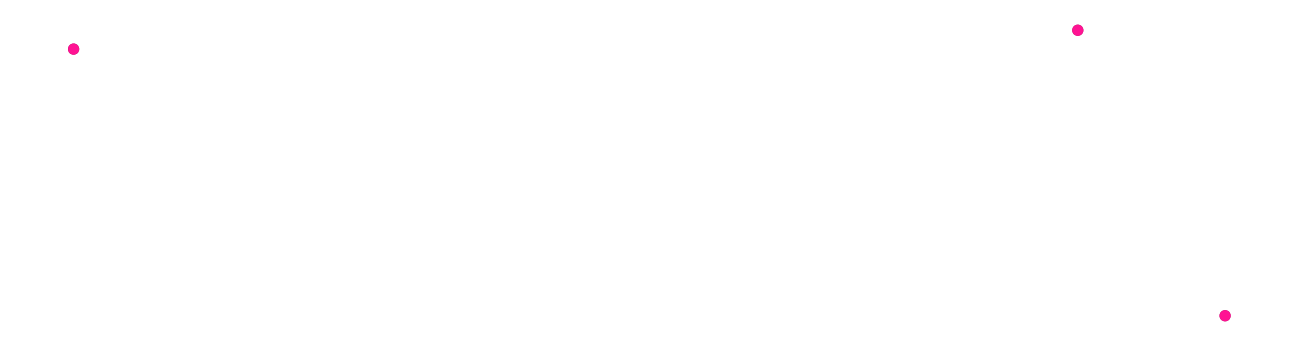

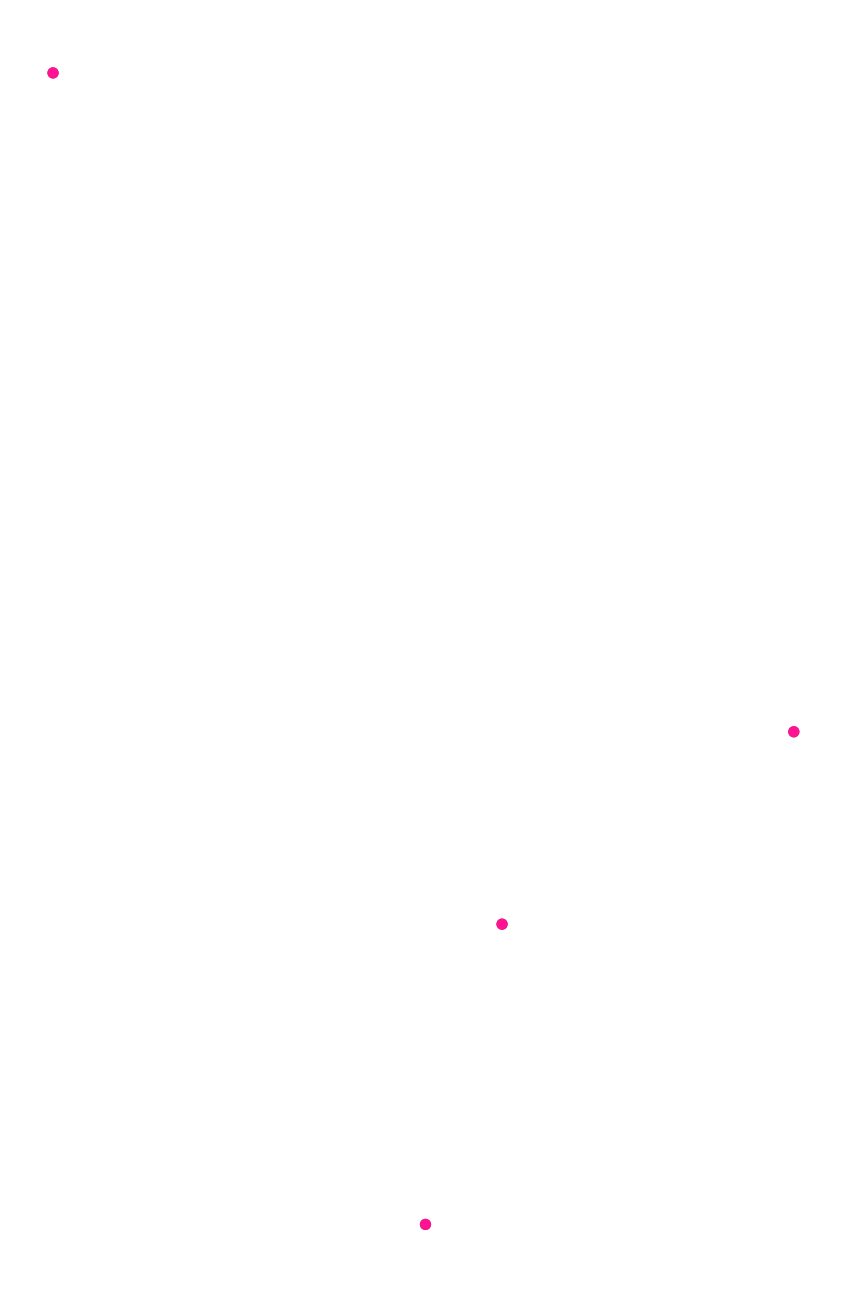

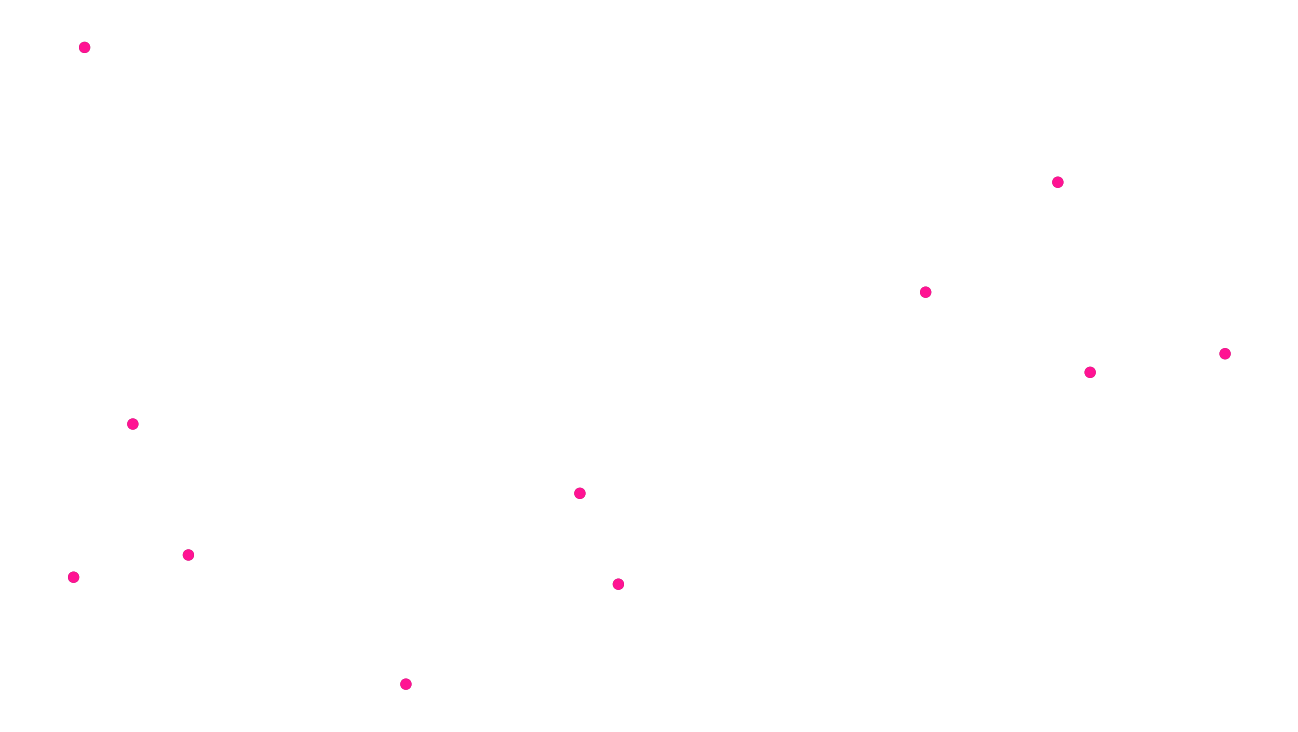

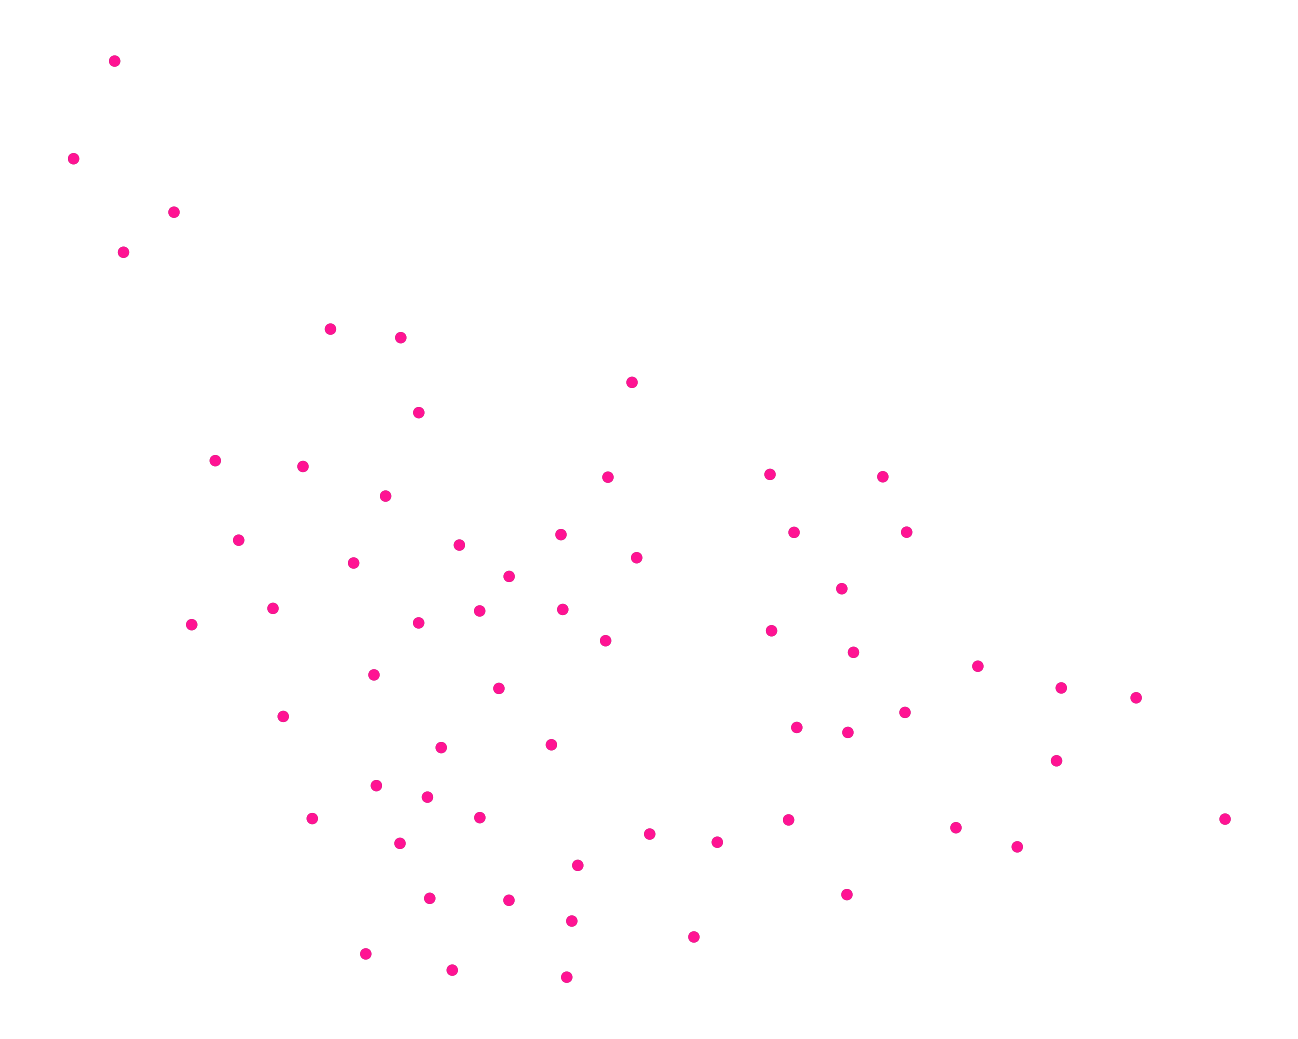

In [13]:
# adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
#                        (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
#                          (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     
                    
HIGHLIGHT_COLOR = "#ff1393"     # Red, as an example
OTHER_COLOR = "#ededed"         # Very light grey

#NICHE="Sebaceous_immune"
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


#sample_counts = adata_5k_i.obs["info_id6"].value_counts()
#samples_to_keep = sample_counts[sample_counts > 100].index

SEB_SAMPLES = []
for i, DONOR_ID in enumerate(SAMPLES):
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == DONOR_ID]
    print(i)
   # print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        #adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        adata_ii = adata_i#[adata_i.obs[NICHE_COLUMN] == NICHE]

        CELL_COUNT = adata_ii.shape[0]
        
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:
            # 1. Make new obs column
            adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
                lambda x: NICHE if x == NICHE else "Other"
            )
            # 2. Force categorical with desired order!
            adata_i.obs[NICHE_COLUMN + "_highlight"] = pd.Categorical(
                adata_i.obs[NICHE_COLUMN + "_highlight"],
                categories=[NICHE, "Other"],
                ordered=True
            )
            # 3. Palette as a list, not a dict
            palette = [HIGHLIGHT_COLOR, OTHER_COLOR]
            from matplotlib.colors import ListedColormap

            palette = ListedColormap([HIGHLIGHT_COLOR, OTHER_COLOR])
            # 4. Plot
            SEB_SAMPLES.append(DONOR_ID)
            print(DONOR_ID)
            sq.pl.spatial_scatter(
                adata_i,
                library_id="spatial",
                shape=None,
                color="lvl5_annotation",
                palette=palette,
                size=100,
                vmax=1,
                title='',
                #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                edgecolor='black',
                linewidth=0.02,
                legend_loc=None,
                groups=["cDC2: MMP12hi", "LC"]
               # save=f"4e_sebimmune_nicheonly_{DONOR_ID}.pdf"
                # ax=ax,
                # legend_loc="on data"
            )

0
Cell count for slide:  354

BK22_Lesional Baseline
1
Cell count for slide:  15

BK23_Non-lesional Baseline


/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


2
Cell count for slide:  135

BK23_Lesional Baseline
3
Cell count for slide:  19

BK18_Lesional Baseline
4


/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


Cell count for slide:  17

BK24_Non-lesional Baseline
5
Cell count for slide:  21

3D_BK22_Lesional_baseline-B2
6
Cell count for slide:  74



/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
/tmp/ipykernel_2057031/1265637766.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


3D_BK22_Lesional_baseline-D2


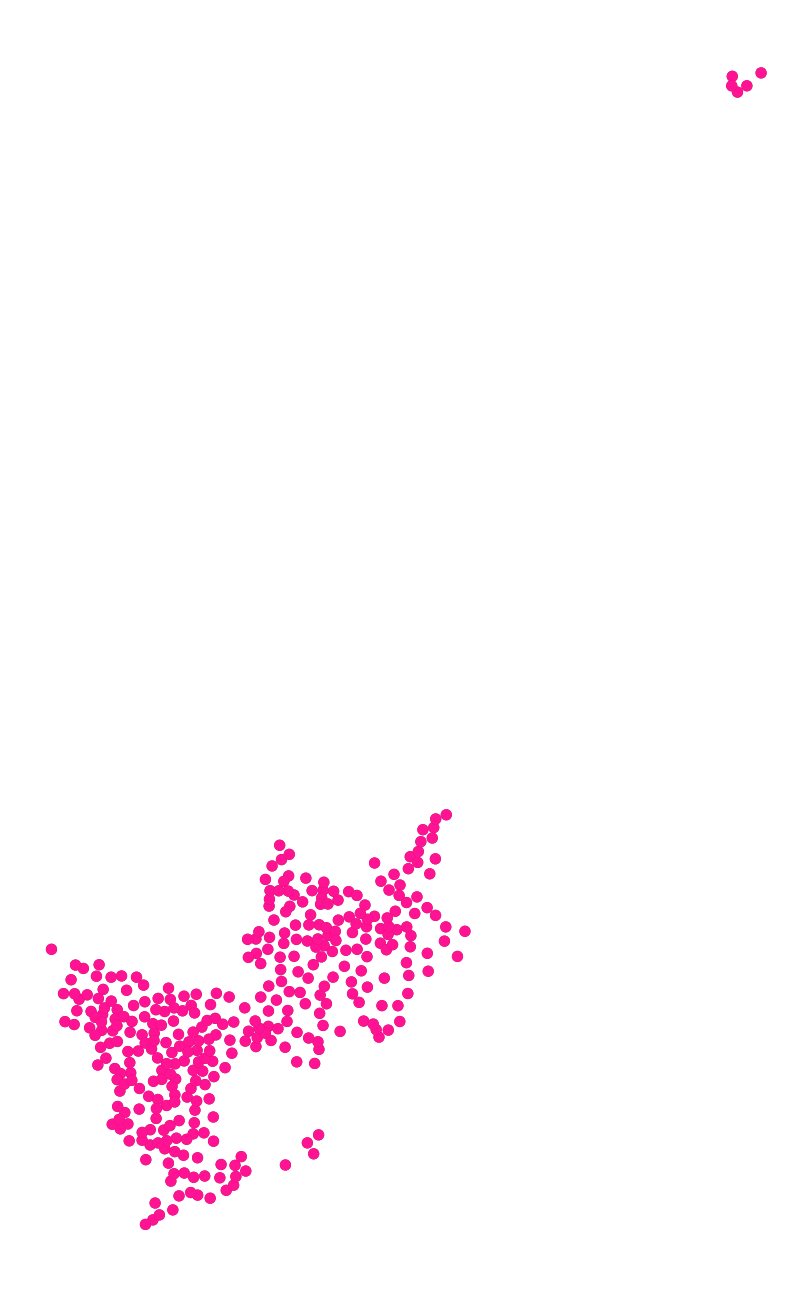

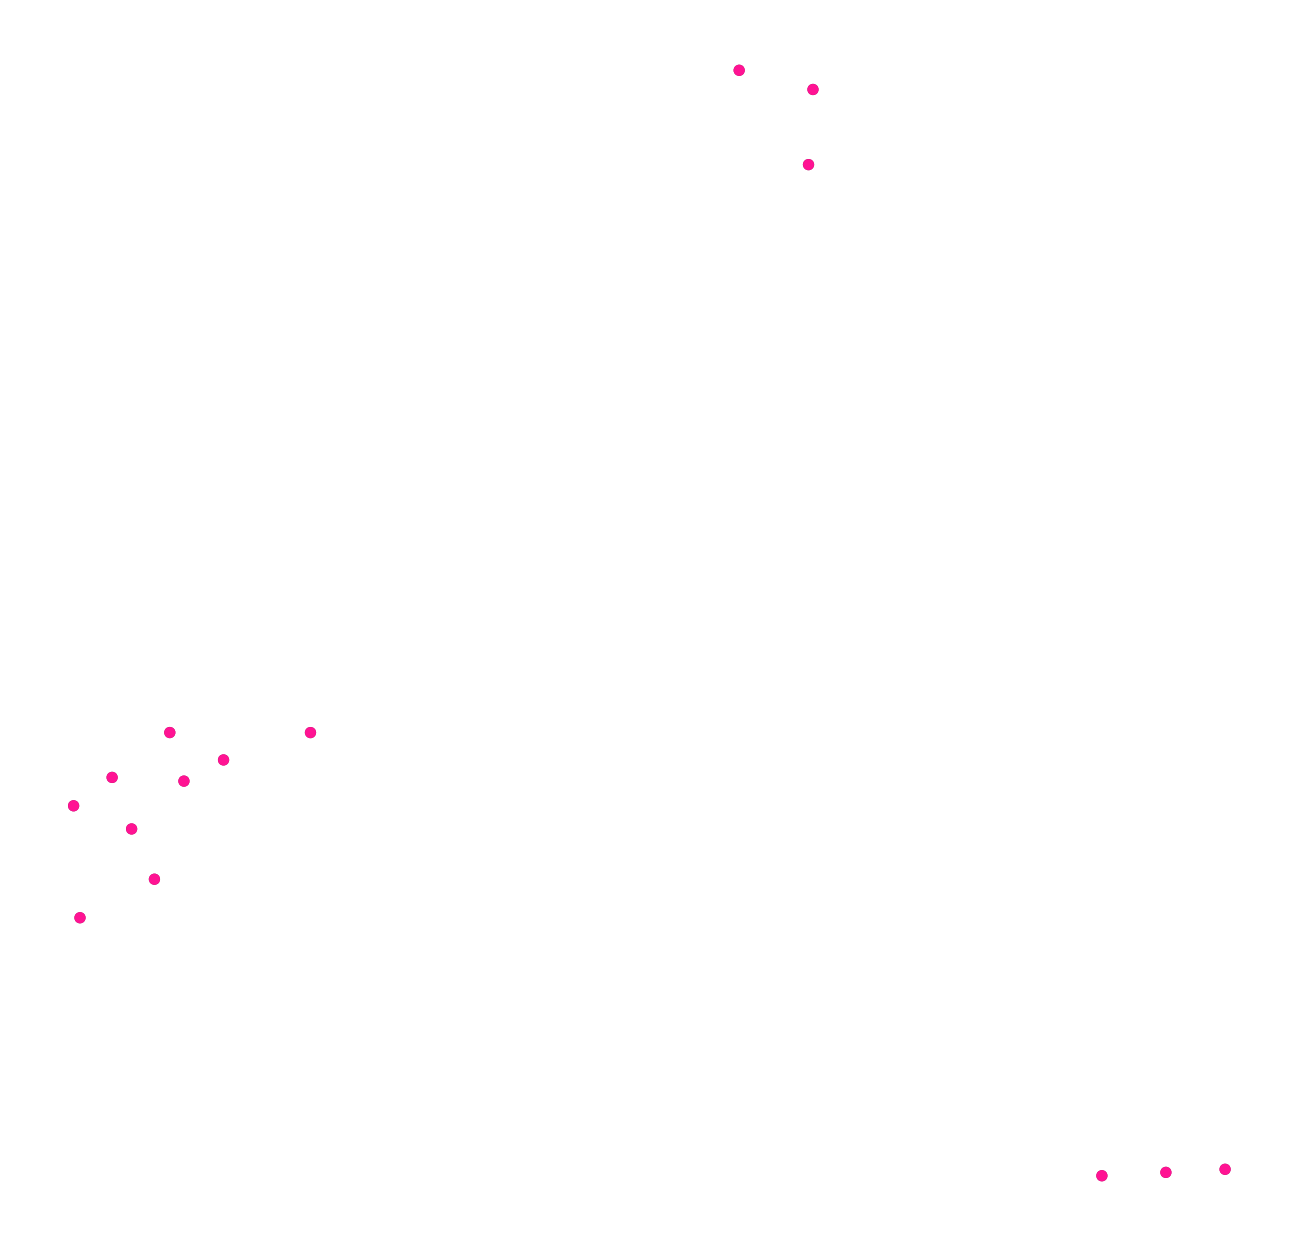

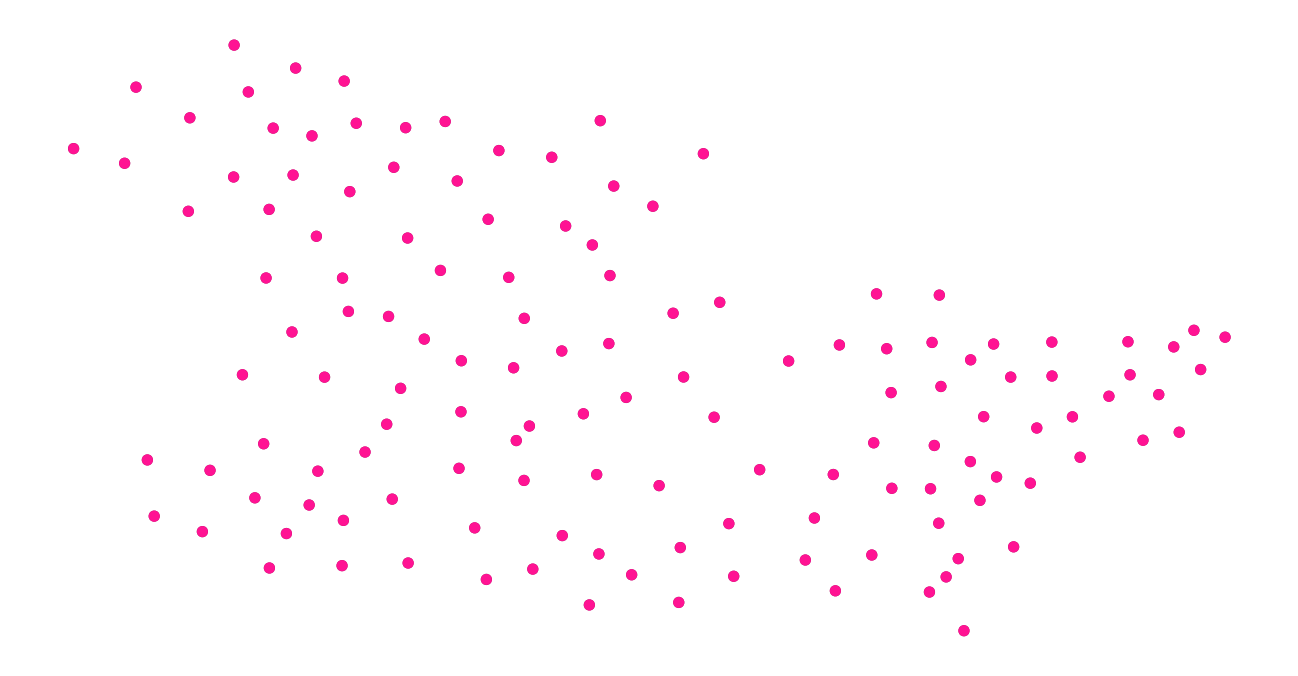

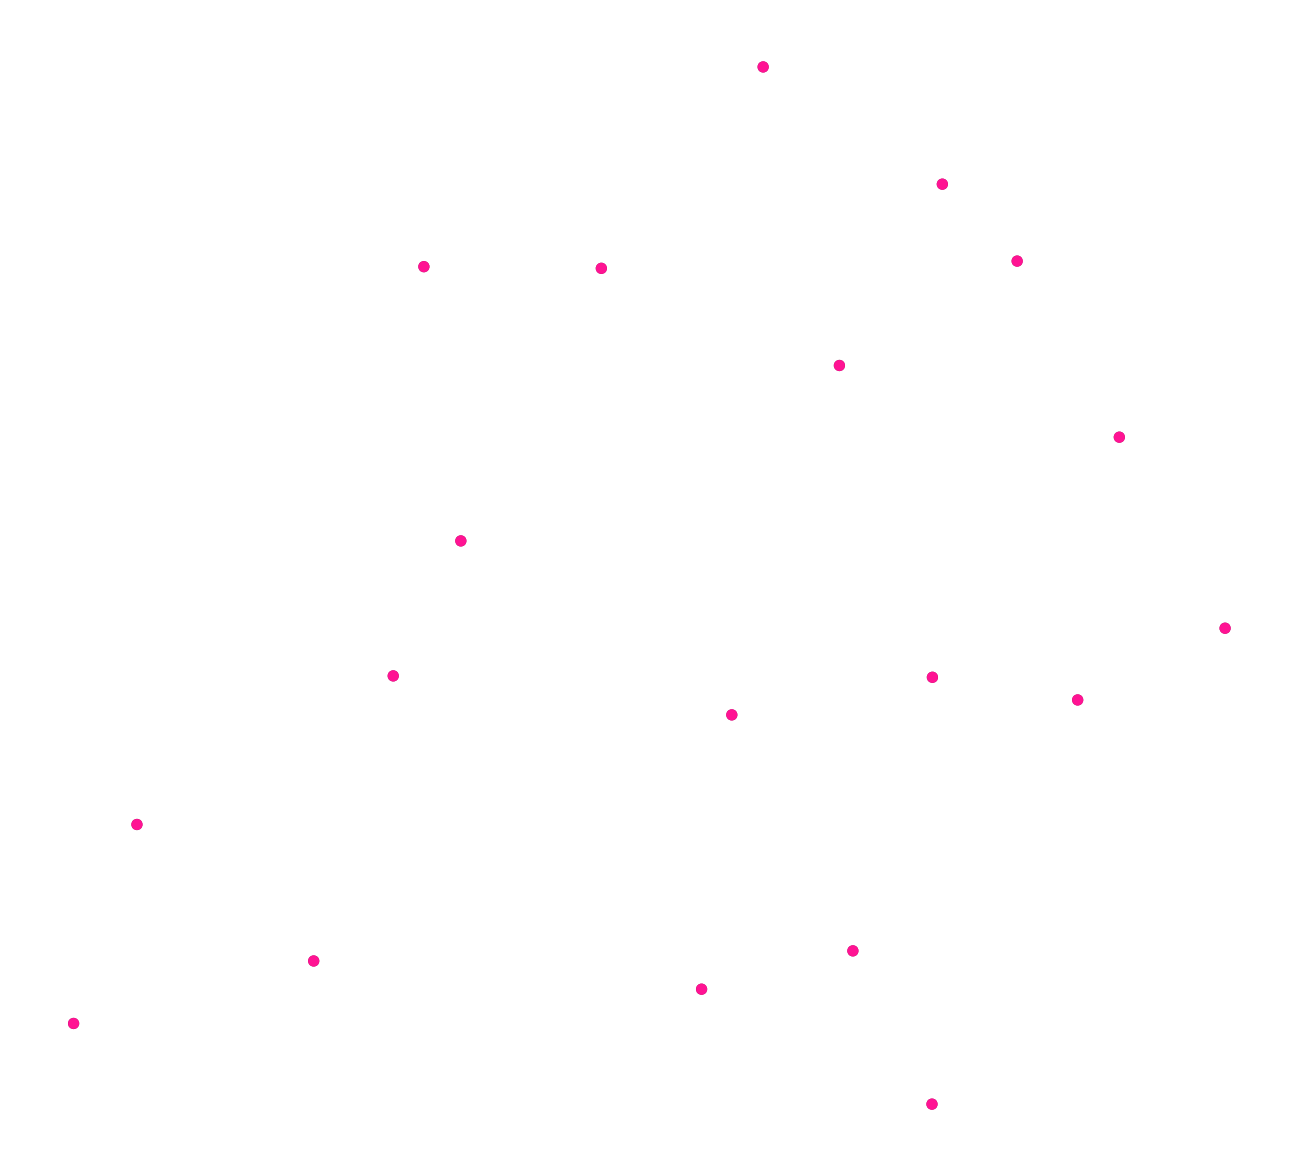

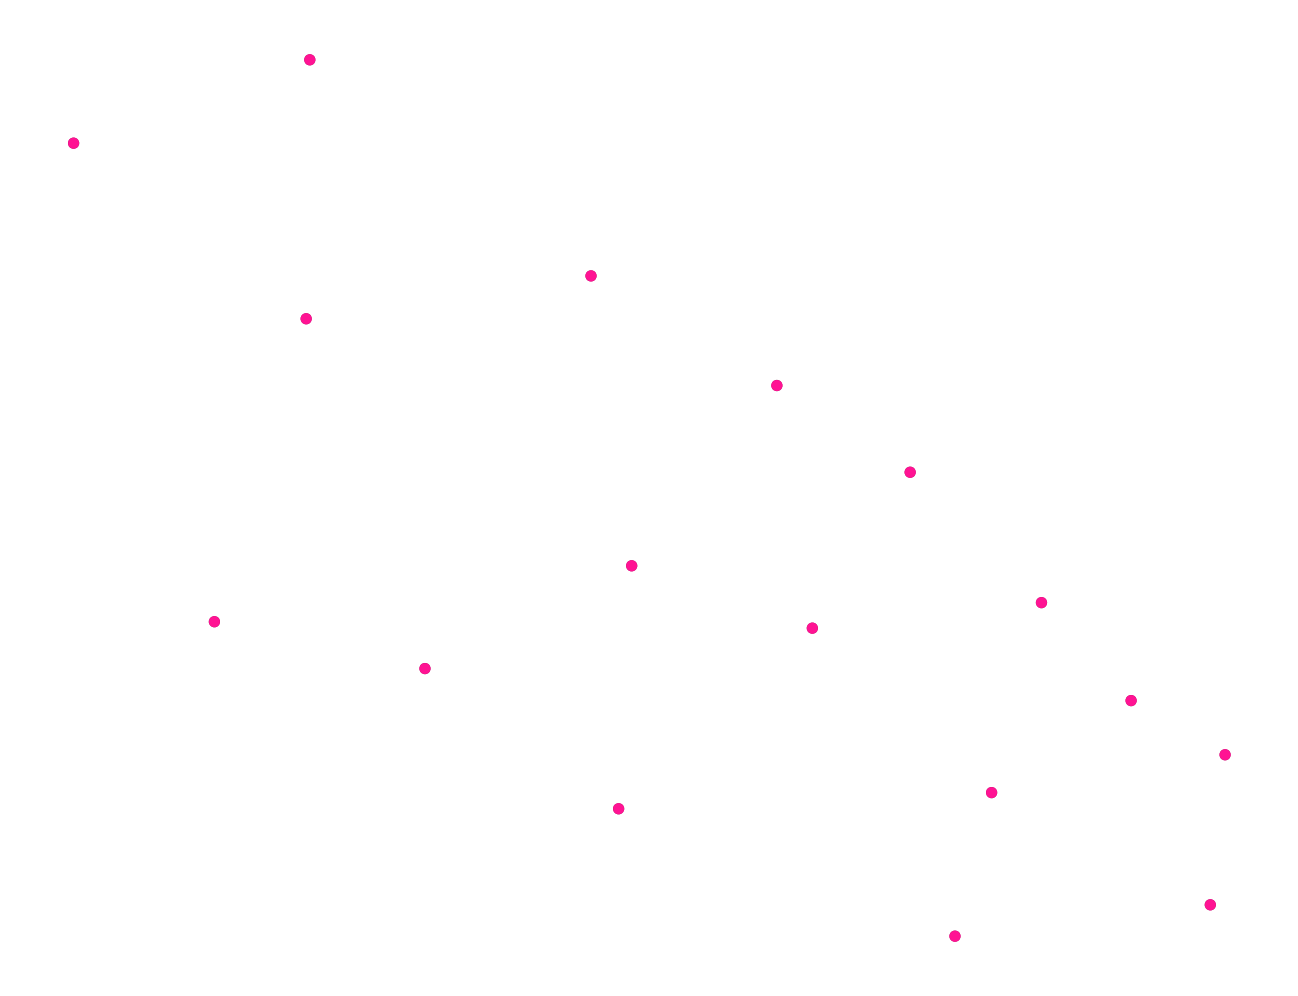

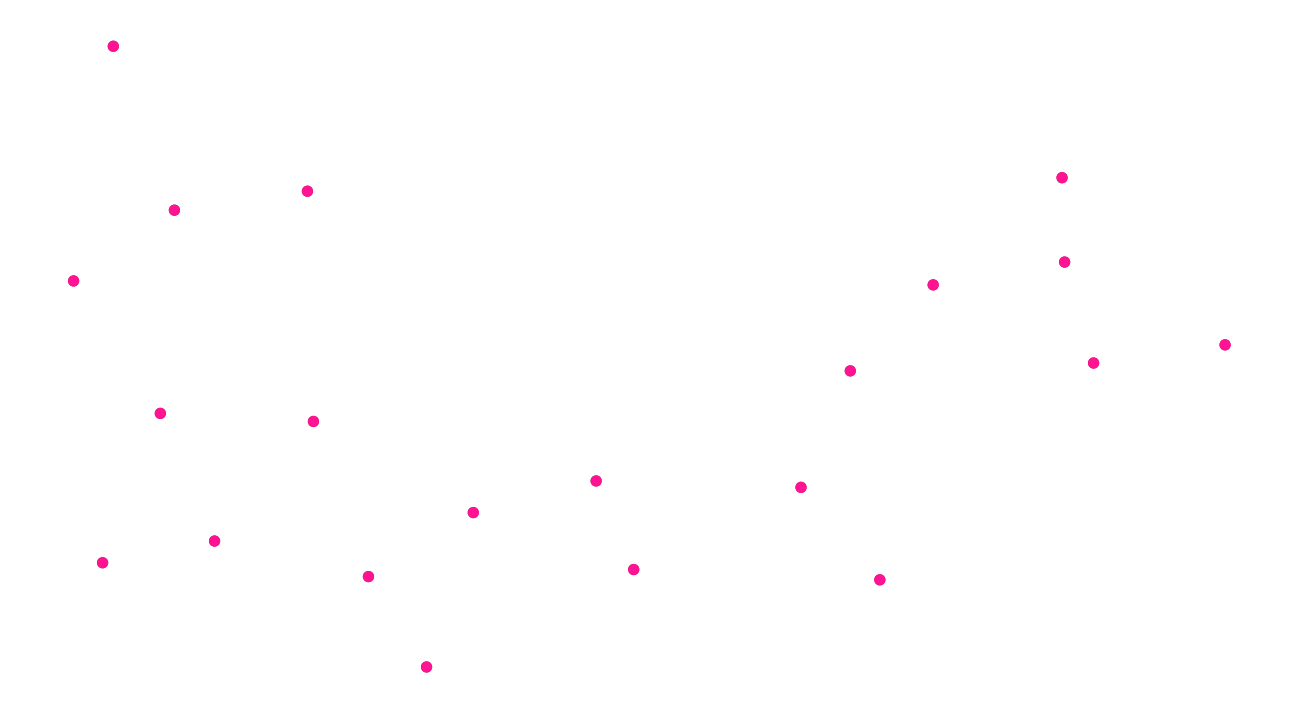

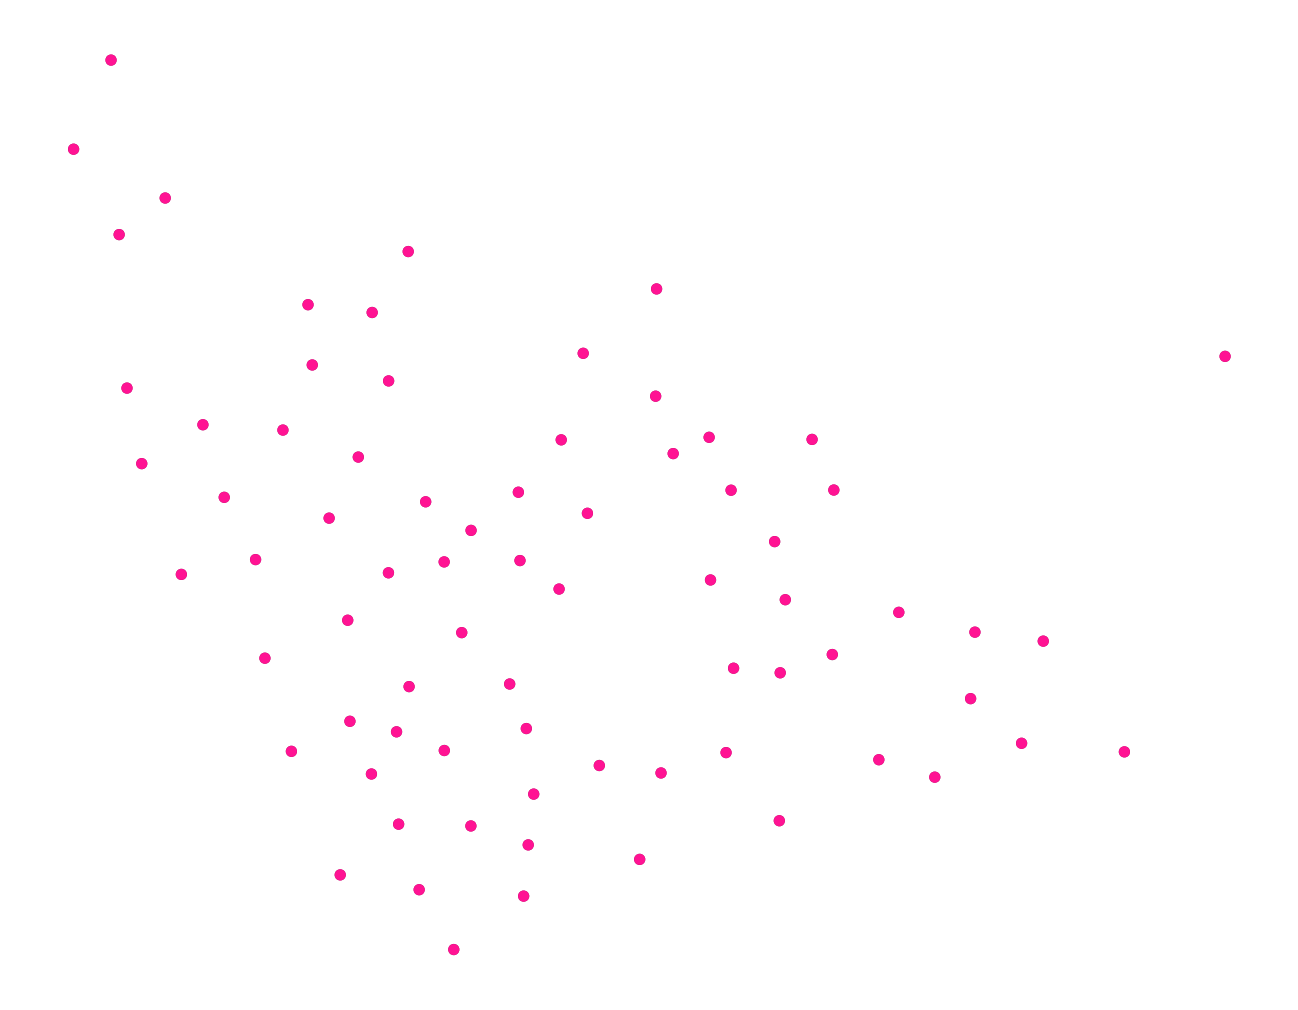

In [14]:
# adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
#                        (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
#                          (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     
                    
HIGHLIGHT_COLOR = "#ff1393"     # Red, as an example
OTHER_COLOR = "#ededed"         # Very light grey

#NICHE="Sebaceous_immune"
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


#sample_counts = adata_5k_i.obs["info_id6"].value_counts()
#samples_to_keep = sample_counts[sample_counts > 100].index

SEB_SAMPLES = []
for i, DONOR_ID in enumerate(SAMPLES):
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == DONOR_ID]
    print(i)
   # print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        CELL_COUNT = adata_ii.shape[0]
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:
            # 1. Make new obs column
            adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
                lambda x: NICHE if x == NICHE else "Other"
            )
            # 2. Force categorical with desired order!
            adata_i.obs[NICHE_COLUMN + "_highlight"] = pd.Categorical(
                adata_i.obs[NICHE_COLUMN + "_highlight"],
                categories=[NICHE, "Other"],
                ordered=True
            )
            # 3. Palette as a list, not a dict
            palette = [HIGHLIGHT_COLOR, OTHER_COLOR]
            from matplotlib.colors import ListedColormap

            palette = ListedColormap([HIGHLIGHT_COLOR, OTHER_COLOR])
            # 4. Plot
            SEB_SAMPLES.append(DONOR_ID)
            print(DONOR_ID)
            sq.pl.spatial_scatter(
                adata_i,
                library_id="spatial",
                shape=None,
                color=NICHE_COLUMN + "_highlight",
                palette=palette,
                size=100,
                vmax=1,
                title='',
                #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                edgecolor='black',
                linewidth=0.02,
                legend_loc=None,
               # save=f"4e_sebimmune_nicheonly_{DONOR_ID}.pdf"
                # ax=ax,
                # legend_loc="on data"
            )

0
Cell count for slide:  21567

BK22_Lesional Baseline


/tmp/ipykernel_2057031/1031678642.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


1
Cell count for slide:  17684

BK23_Non-lesional Baseline


/tmp/ipykernel_2057031/1031678642.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


2
Cell count for slide:  24433

BK23_Lesional Baseline


...

/tmp/ipykernel_2057031/1031678642.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


5
Cell count for slide:  24315

3D_BK22_Lesional_baseline-B2


/tmp/ipykernel_2057031/1031678642.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


6
Cell count for slide:  20714

3D_BK22_Lesional_baseline-D2


/tmp/ipykernel_2057031/1031678642.py:35: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(


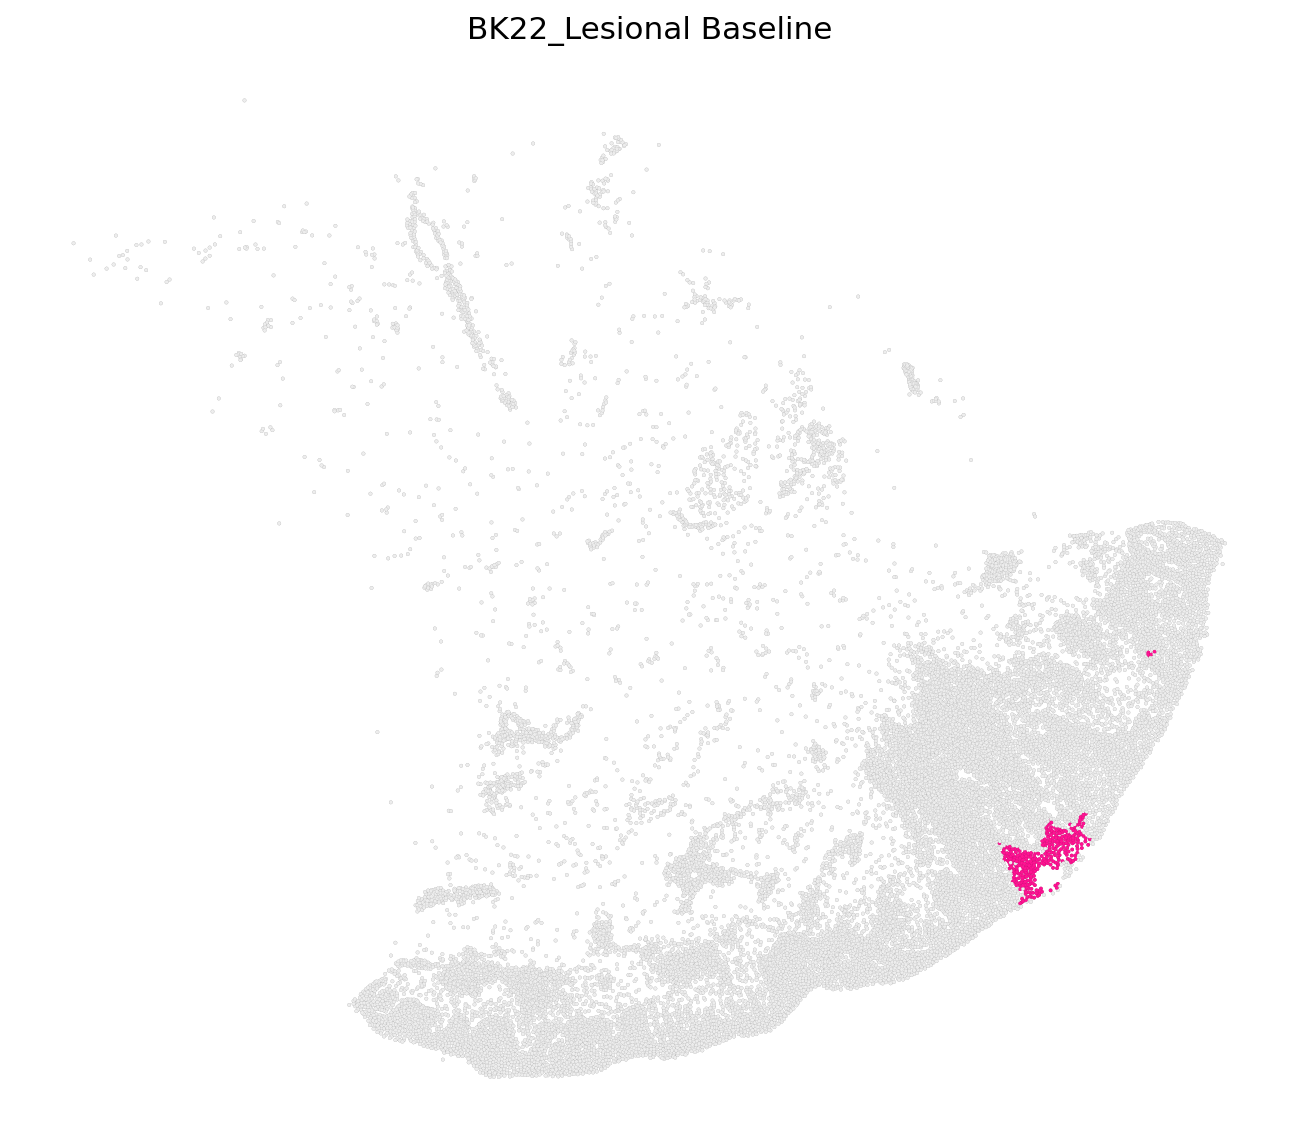

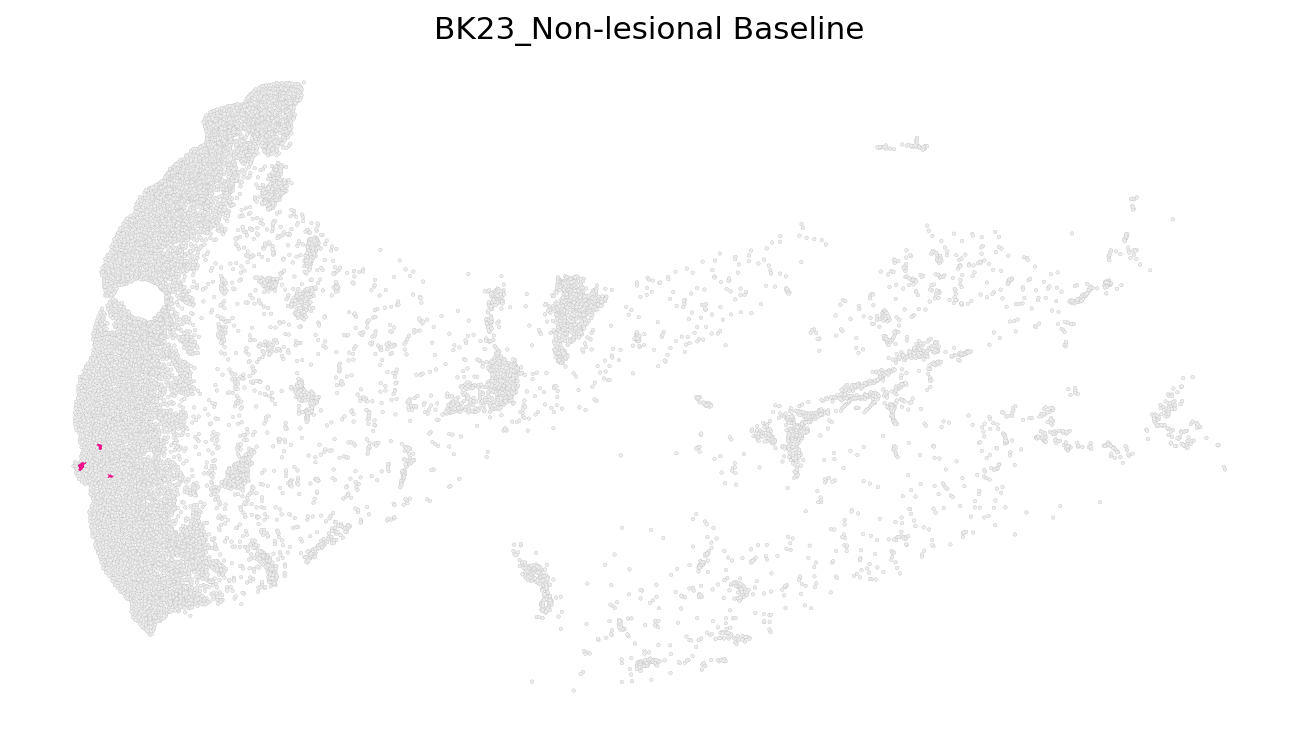

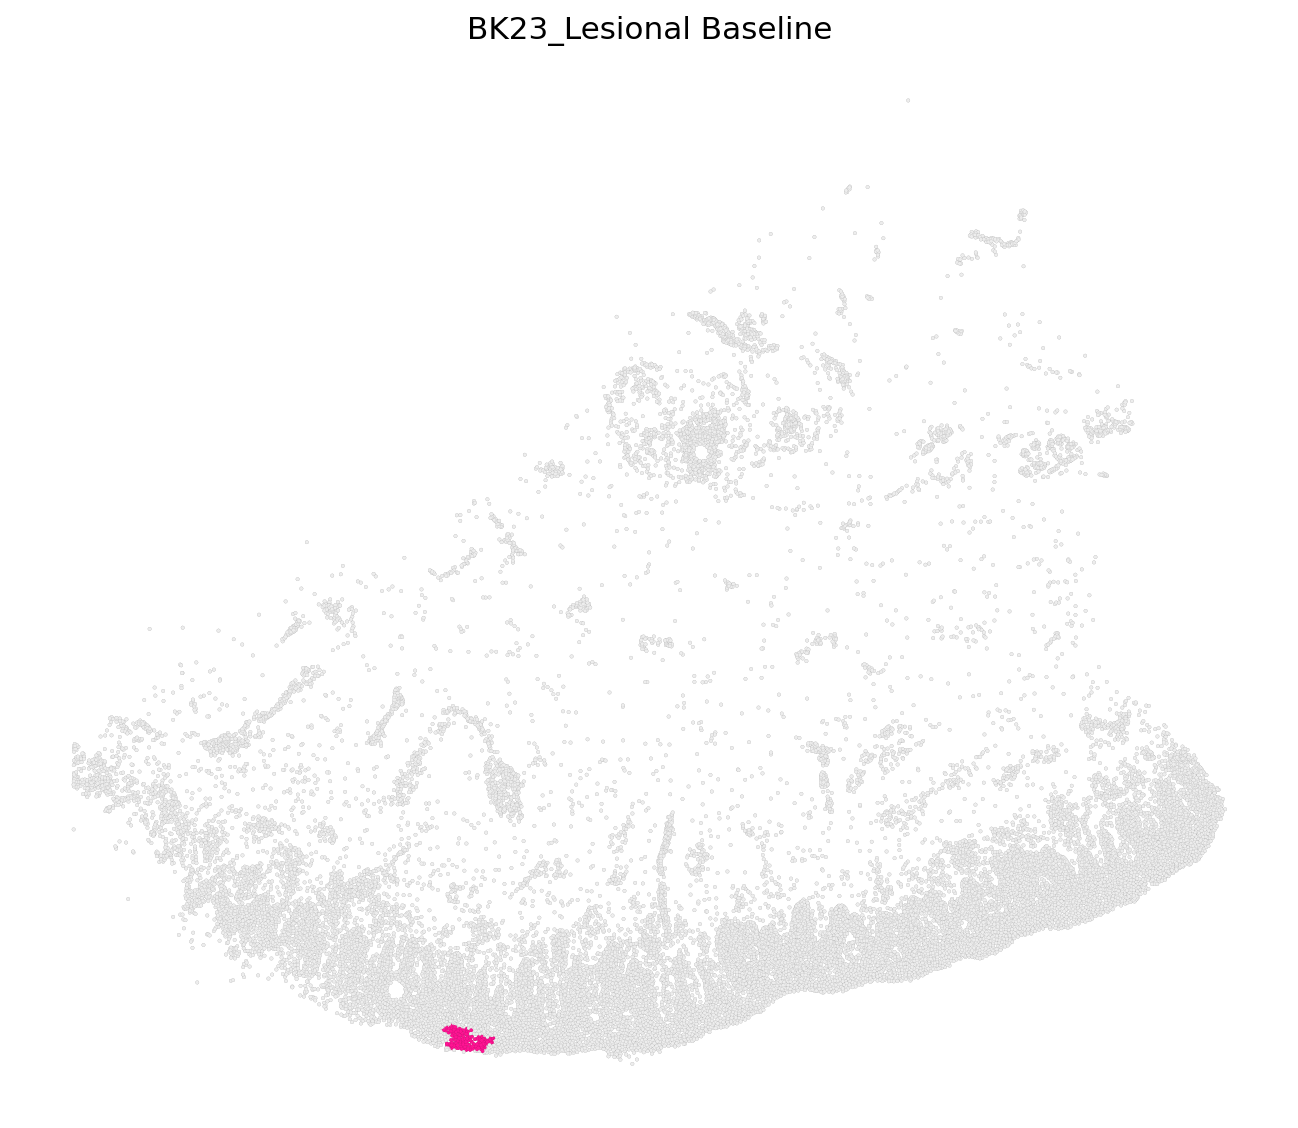

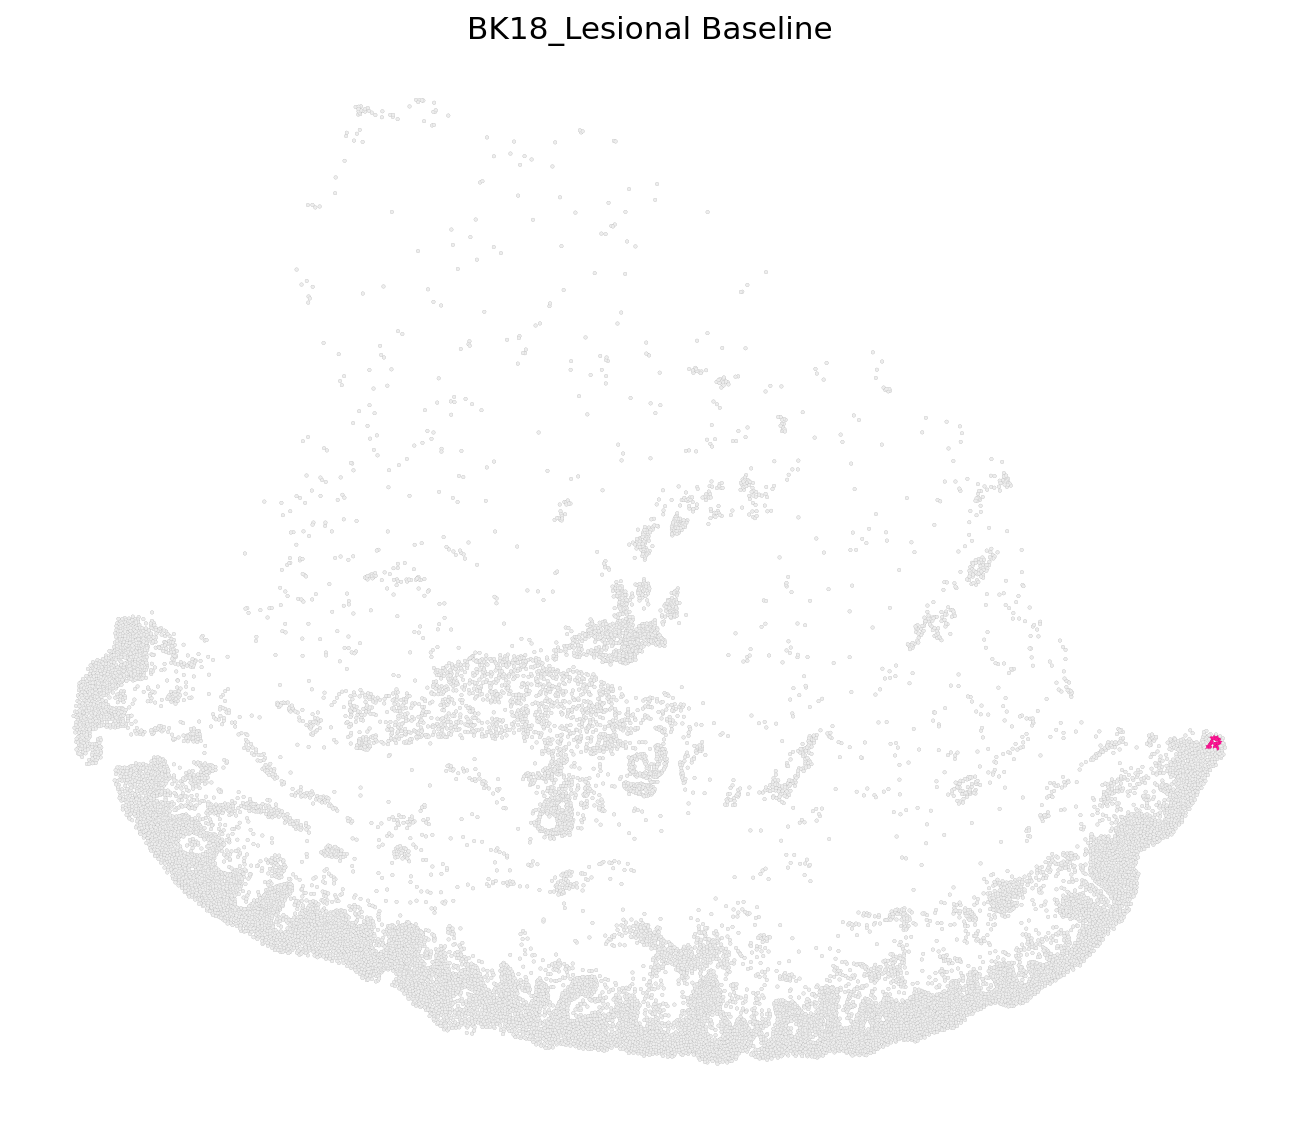

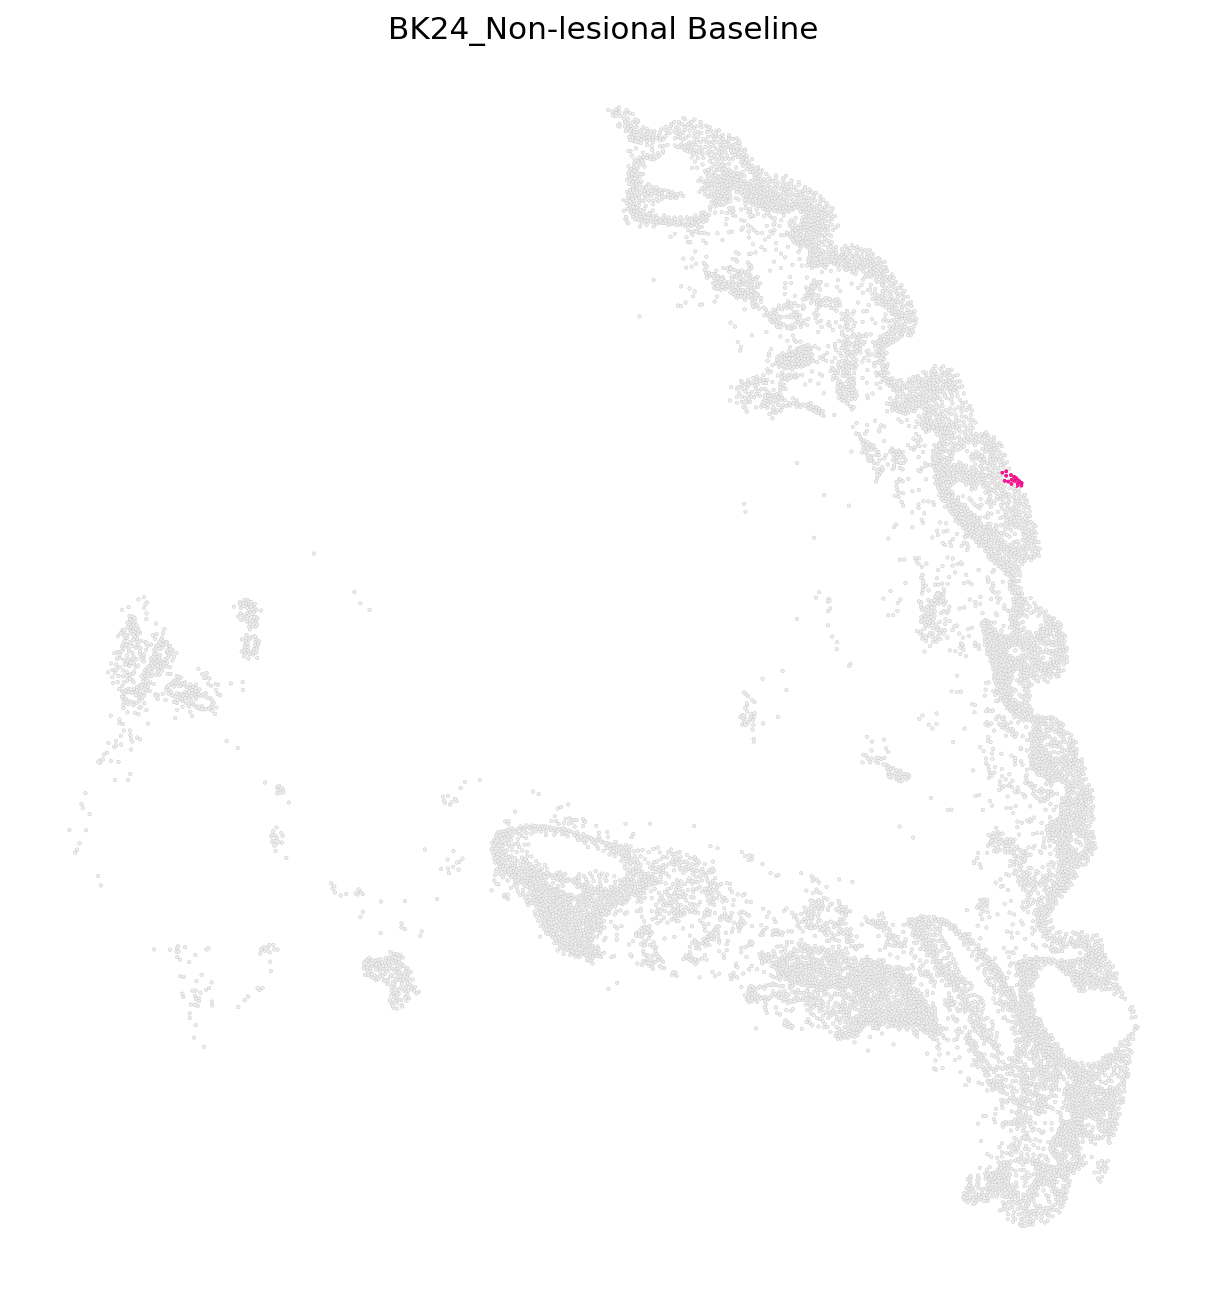

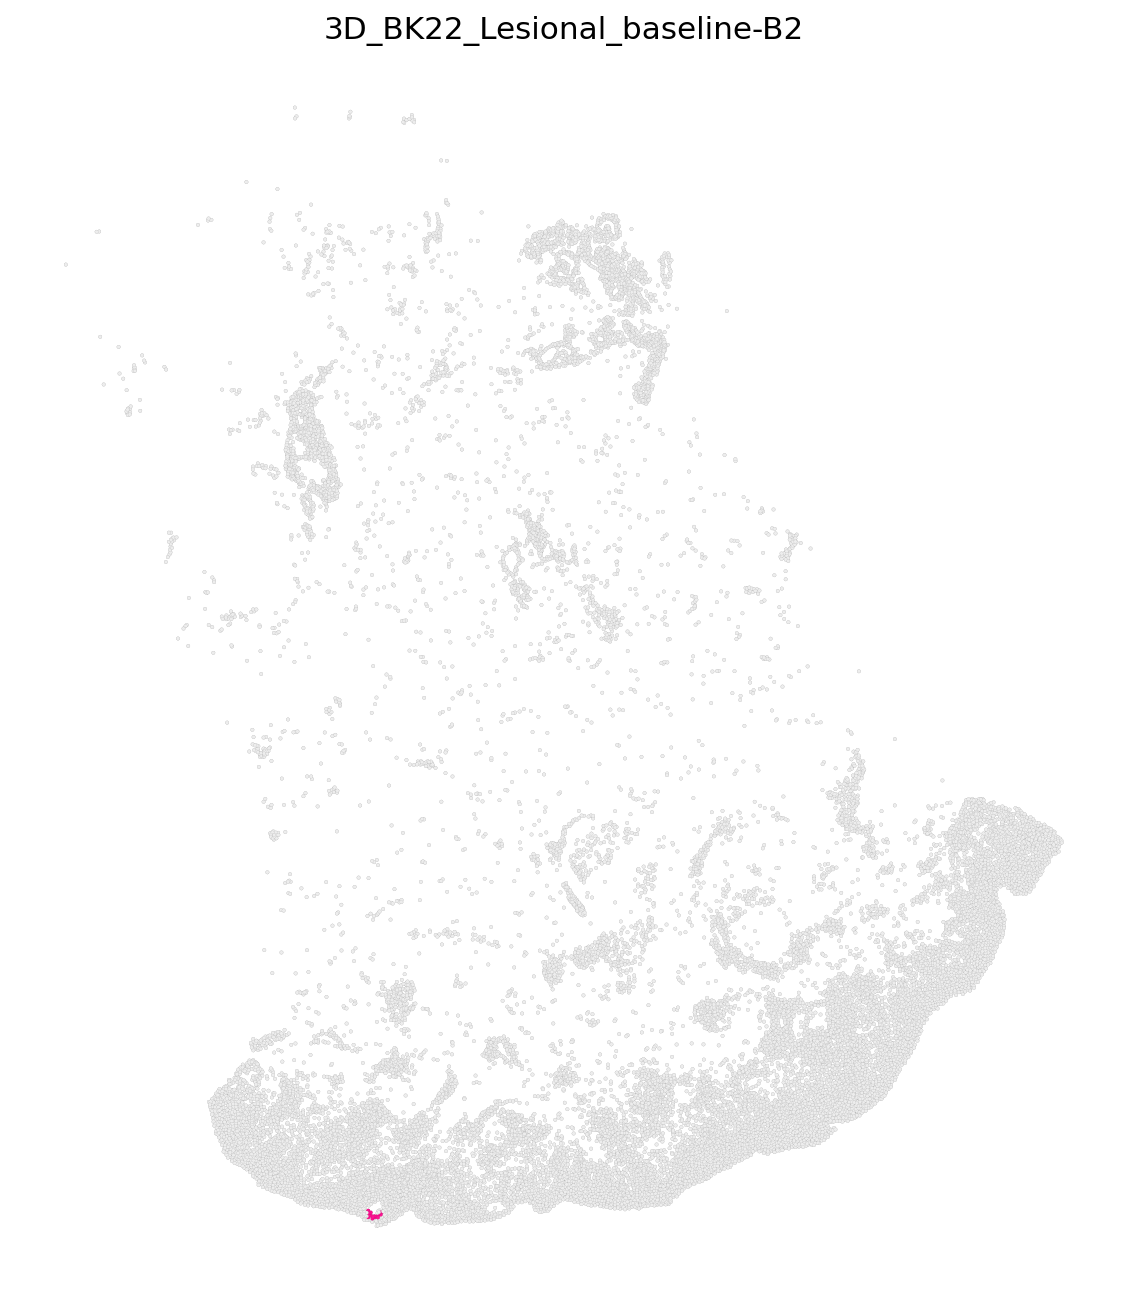

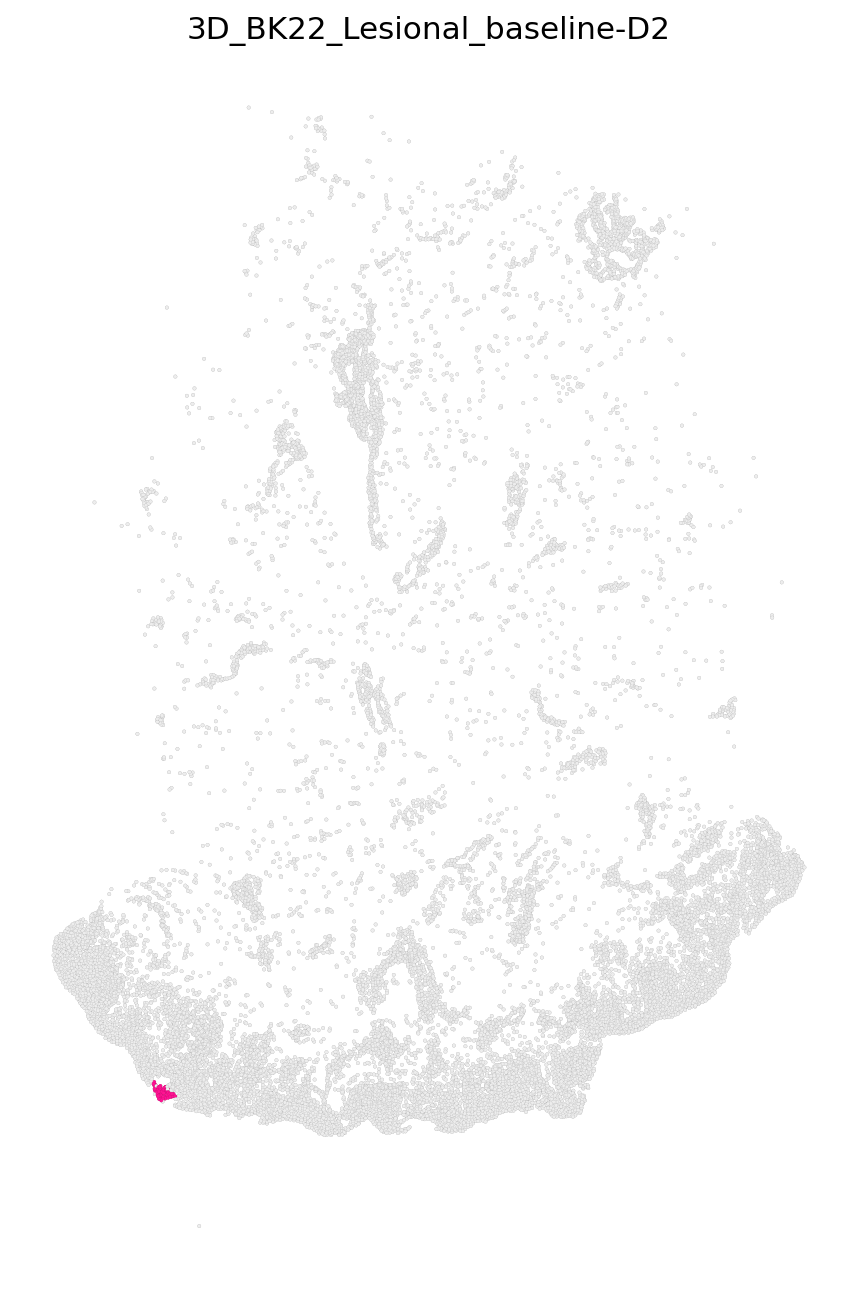

In [15]:
# adata_5k_i = adata_5k[(adata_5k.obs["lvl5_annotation"].str.startswith("Seb"))|
#                        (adata_5k.obs["lvl5_annotation"].str.startswith("KC"))|
#                          (adata_5k.obs["niche19"].str.startswith("Seb"))]
                     
                    
HIGHLIGHT_COLOR = "#ff1393"     # Red, as an example
OTHER_COLOR = "#ededed"         # Very light grey

#NICHE="Sebaceous_immune"
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))


#sample_counts = adata_5k_i.obs["info_id6"].value_counts()
#samples_to_keep = sample_counts[sample_counts > 100].index

SEB_SAMPLES = []
for i, DONOR_ID in enumerate(SAMPLES):
    adata_i = adata_5k[adata_5k.obs["info_id6"] == DONOR_ID]
    print(i)
   # print(i+1, "/", len(samples_to_keep))
    STATUS = adata_i.obs["Site_status"].unique()[0]
    TIMEPOINT = adata_i.obs["Timepoint"].unique()[0]
    DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
    INFO_ID = list(adata_i.obs.info_id.unique())[0]
    niche_names_found = adata_i.obs[NICHE_COLUMN].unique()
   
    if NICHE in niche_names_found:
        adata_ii = adata_i
        #adata_ii = adata_i[adata_i.obs[NICHE_COLUMN] == NICHE]
        CELL_COUNT = adata_ii.shape[0]
        print("Cell count for slide: ", CELL_COUNT)
        print()
        if CELL_COUNT > 10:
            # 1. Make new obs column
            adata_i.obs[NICHE_COLUMN + "_highlight"] = adata_i.obs[NICHE_COLUMN].apply(
                lambda x: NICHE if x == NICHE else "Other"
            )
            # 2. Force categorical with desired order!
            adata_i.obs[NICHE_COLUMN + "_highlight"] = pd.Categorical(
                adata_i.obs[NICHE_COLUMN + "_highlight"],
                categories=[NICHE, "Other"],
                ordered=True
            )
            # 3. Palette as a list, not a dict
            palette = [HIGHLIGHT_COLOR, OTHER_COLOR]
            from matplotlib.colors import ListedColormap

            palette = ListedColormap([HIGHLIGHT_COLOR, OTHER_COLOR])
            # 4. Plot
            SEB_SAMPLES.append(DONOR_ID)
            print(DONOR_ID)
            sq.pl.spatial_scatter(
                adata_i,
                library_id="spatial",
                shape=None,
                color=NICHE_COLUMN + "_highlight",
                palette=palette,
                size=10,
                vmax=1,
                #title=f"{DONOR_ID}_{STATUS}_{TIMEPOINT}_{DONOR}_n={CELL_COUNT}",
                edgecolor='black',
                linewidth=0.02,
                legend_loc=None,
                title=DONOR_ID,
               # save=f"4e_sebimmune_nicheonly_{DONOR_ID}.pdf"
                # ax=ax,
                # legend_loc="on data"
            )
             

In [16]:
adata_5k_i.obs.lvl5_annotation.value_counts()

lvl5_annotation
KC3                 271
cDC2: MMP12hi       185
TRM_IL13+            35
MigDC (cDC2)         26
cDC2: EREG+CCR7+     23
KC5                  19
KC1                  11
Tnaive               11
T                    10
Treg                  8
Treg_LRRC32+          5
cDC2                  5
cDC1                  5
cDC                   4
Th                    4
Melanocyte            2
Mac2                  2
LC                    2
KC2                   2
Tc0                   2
MigDC (cDC1)          1
T_Prolif              1
TransitionalDC        1
Name: count, dtype: int64

In [17]:
RENAME = {"KC1": "KC",
         "KC5": "KC",
          "KC3": "KC",
          "Treg": "Other T",
          
           "Treg_LRRC32+": "Other T",
                     "Tnaive": "Other T",
          "KC2": "KC",
          "T_Prolif": "Other T",
          "MigDC (cDC1)": "cDC1",
          "Tc0": "Other T",
          "Th": 'Other T',
          "T": 'Other T',

         }
adata_5k_i.obs["tmp"]=adata_5k_i.obs.lvl5_annotation.map(RENAME)
adata_5k_i.obs["lvl5_annotation"]=adata_5k_i.obs["tmp"].fillna(adata_5k_i.obs["lvl5_annotation"])

/tmp/ipykernel_2057031/2265613251.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k_i.obs["tmp"]=adata_5k_i.obs.lvl5_annotation.map(RENAME)


In [18]:
colors["KC1"]

'#3a4e7a'

In [19]:

# colors=colors|
adata_5k_i.obs.lvl5_annotation.value_counts()# colors=colors|
adata_5k_i.obs.lvl5_annotation.value_counts()

lvl5_annotation
KC                  303
cDC2: MMP12hi       185
Other T              41
TRM_IL13+            35
MigDC (cDC2)         26
cDC2: EREG+CCR7+     23
cDC1                  6
cDC2                  5
cDC                   4
Mac2                  2
LC                    2
Melanocyte            2
TransitionalDC        1
Name: count, dtype: int64

/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


(354, 4993)


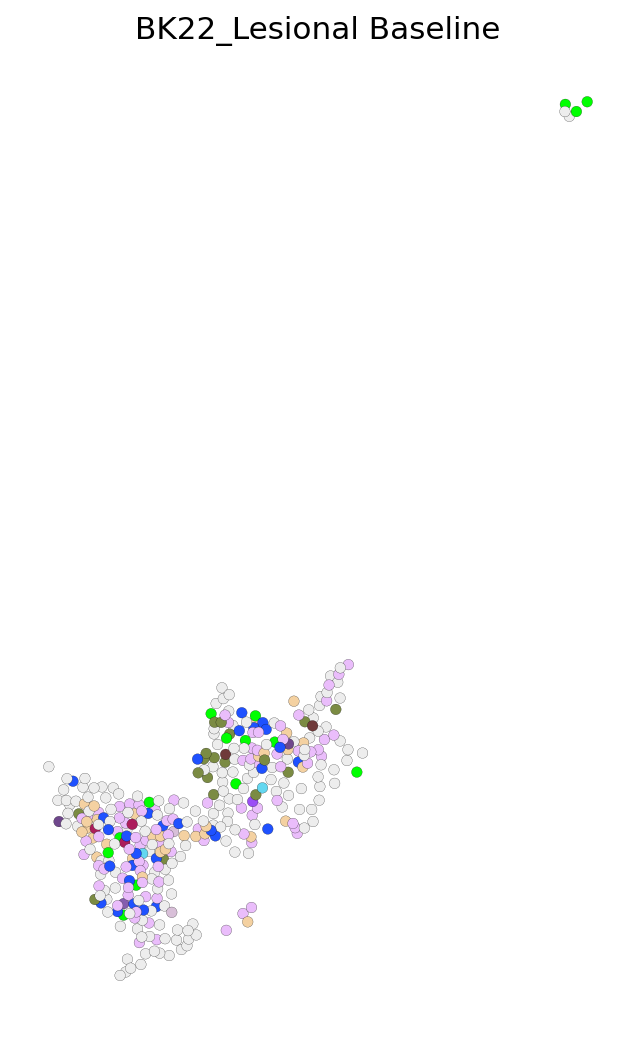

(15, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


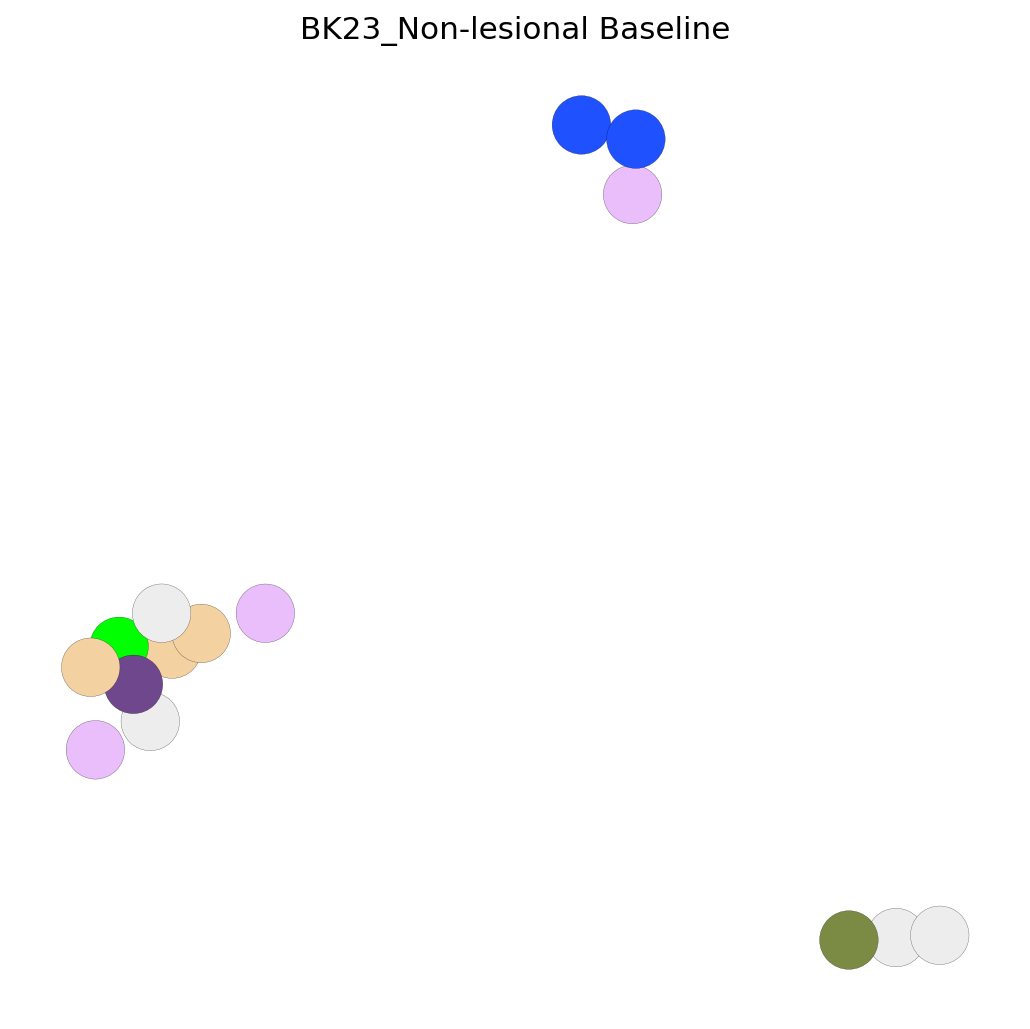

(135, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


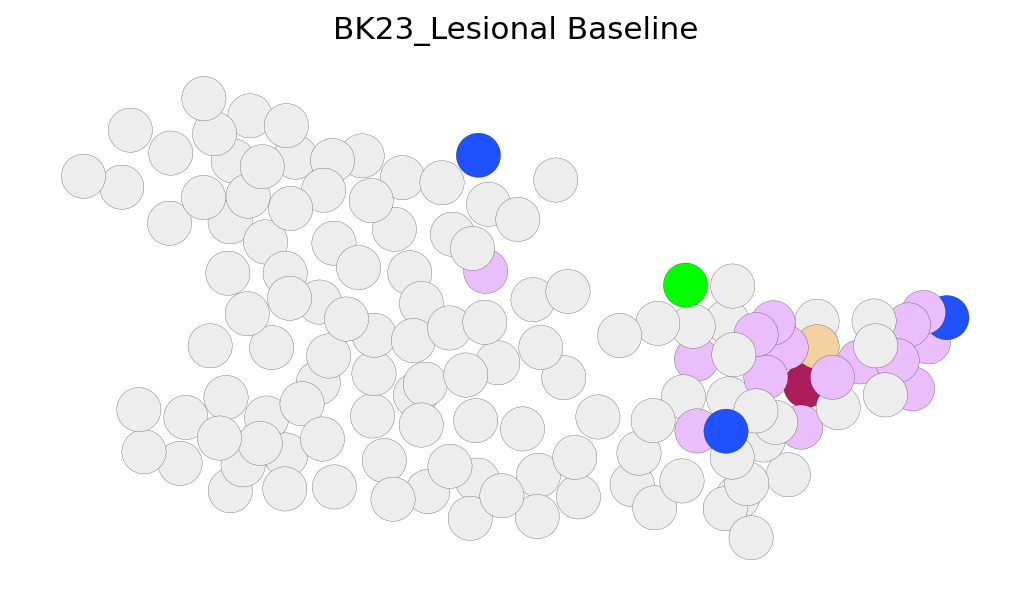

(19, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


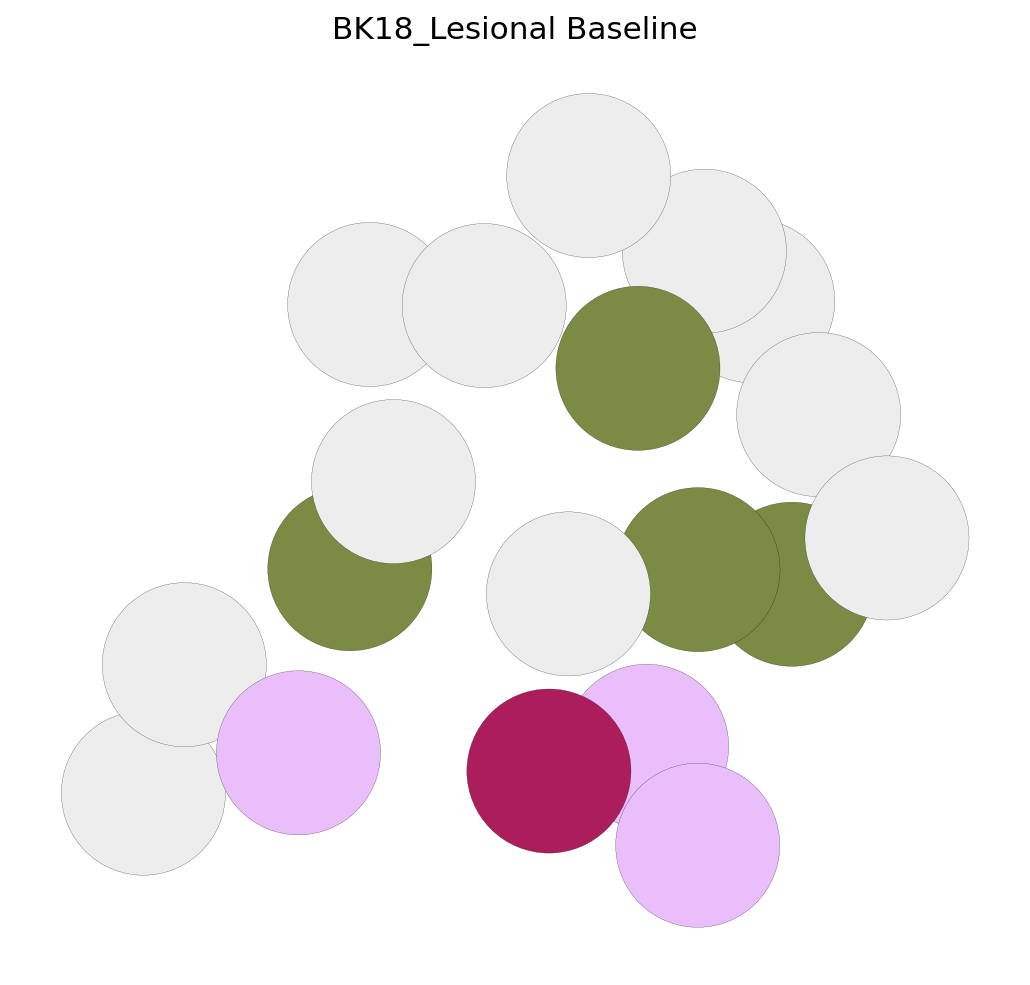

(17, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


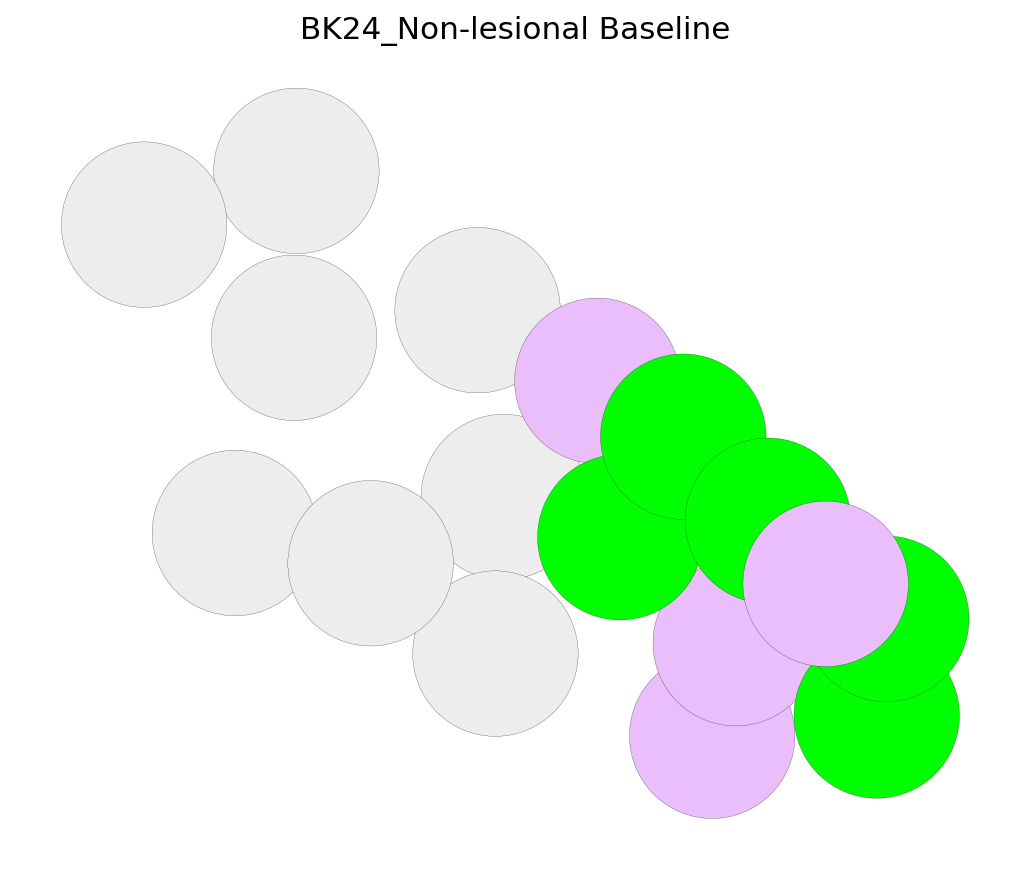

(21, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


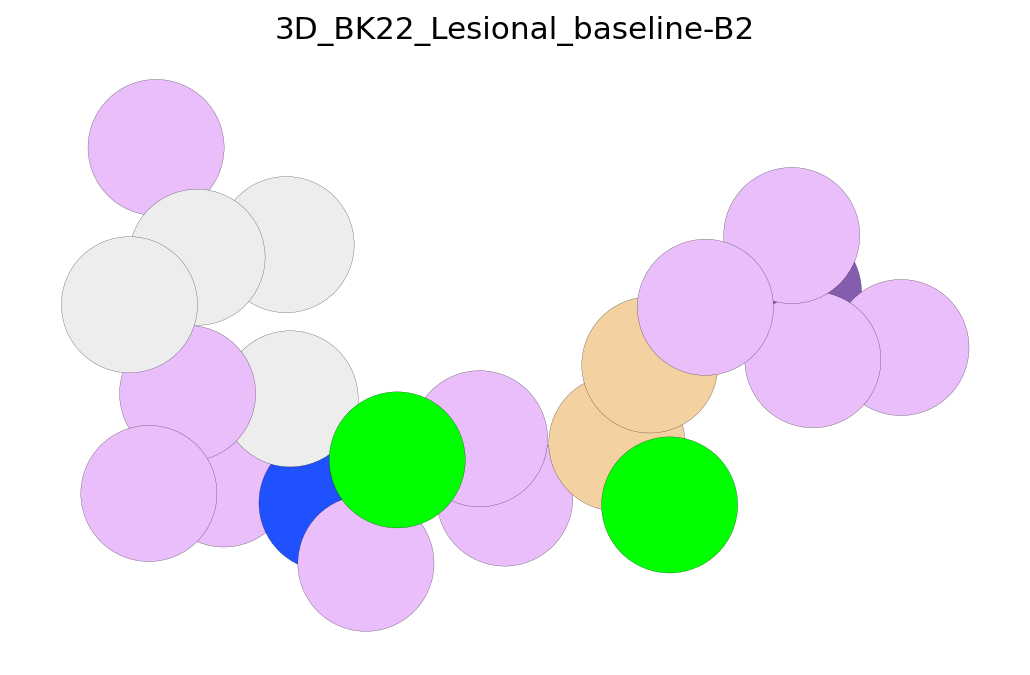

(74, 4993)


/tmp/ipykernel_2057031/874093417.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


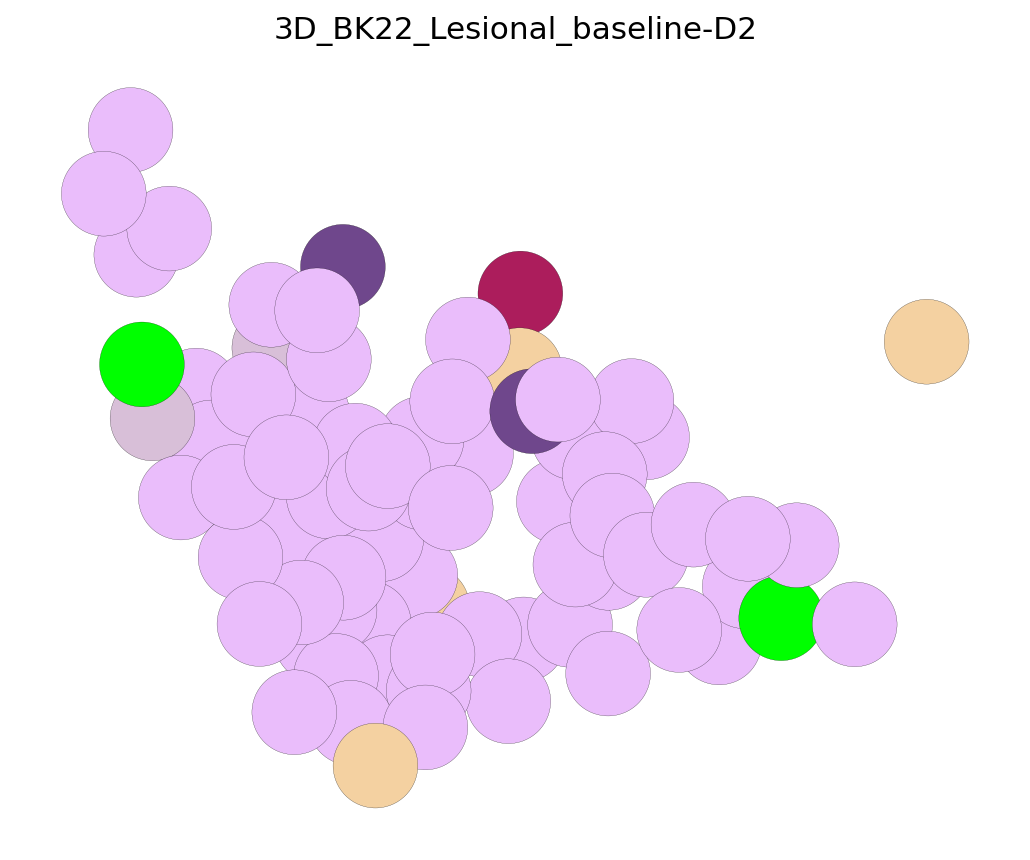

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


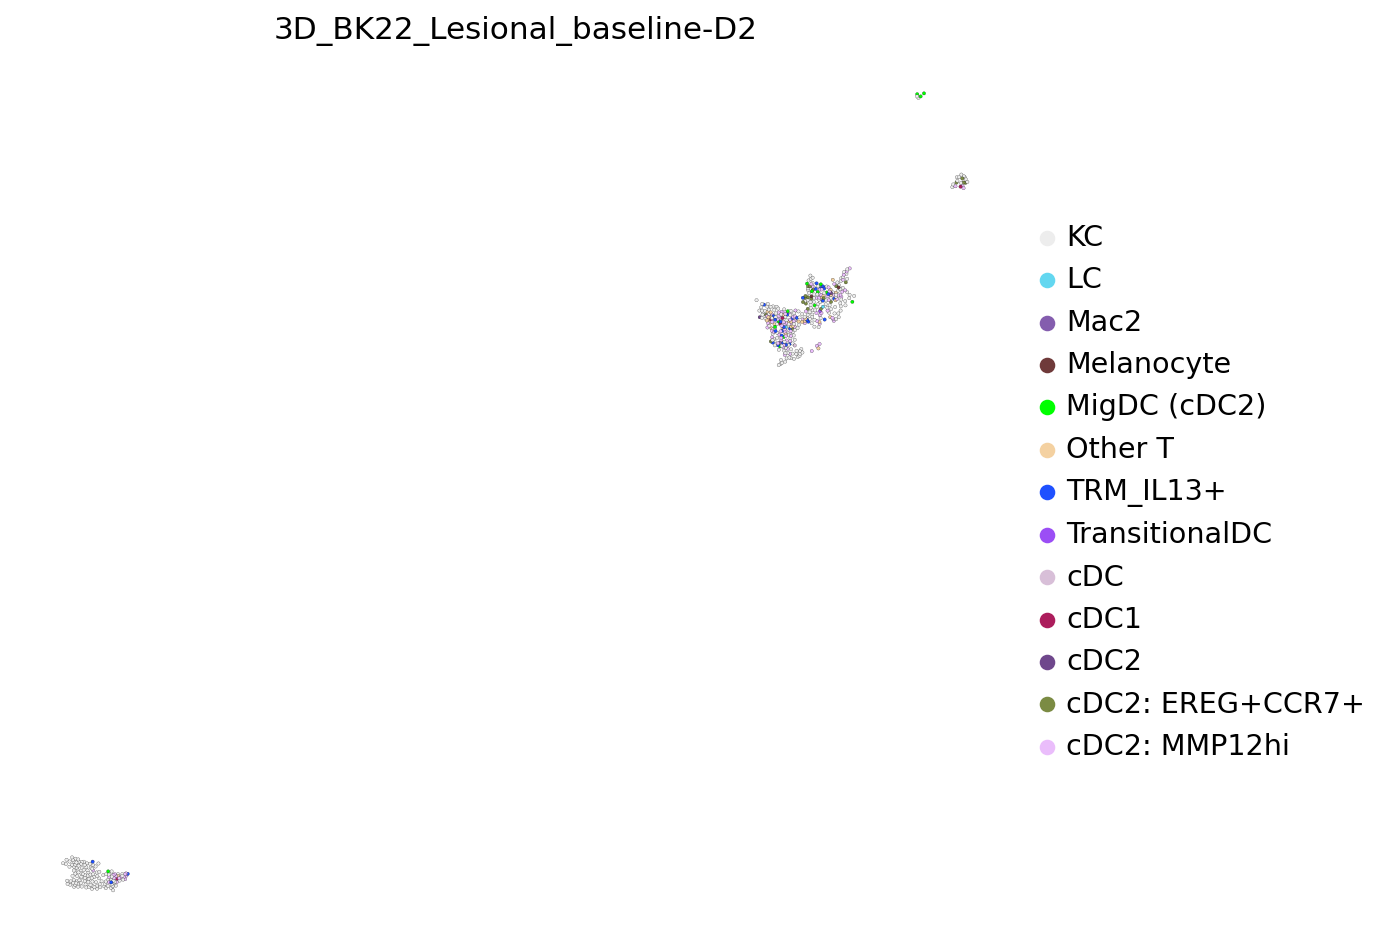

In [20]:
# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------
# KEEP_CT   = [#'KC3',
#     'cDC2: MMP12hi',  'LC',
#    # 'TRM_IL13+', 
#     'MigDC (cDC2)',
#                   'cDC2: EREG+CCR7+',
#     #'KC5', 'KC1', 'Tnaive', 'T', 'Treg',
#                   'cDC1',# 'Treg_LRRC32+', 
#     'cDC2']
import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

with open(file_path, 'rb') as file:
    colors = pickle.load(file)
OTHER_CLR = "#ededed"

for i, slide_id in enumerate(SAMPLES):
#['BK22_Lesional Baseline',  "BK23_Lesional Baseline", "BK18_Lesional Baseline"] :                    # ←  your existing loop
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    # --------------------------------------------------------------
    # 1.  build new annotation column
    # --------------------------------------------------------------
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

#    filt = annos.where(annos.isin(KEEP_CT), "Other")
 #   filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
  #  adata_i.obs["lvl5_filtered"] = filt
   # print(adata_i.shape)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    
    adata_i.obs["lvl5_filtered"] = adata_i.obs["lvl5_annotation"]
    # pd.Categorical(
    #     annos.where(annos.isin(KEEP_CT), "Other"),
    #     categories=KEEP_CT + ["Other"],
    #     ordered=True,
    # )

    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in adata_i.obs["lvl5_filtered"].unique()
    ]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
                            color= "lvl5_filtered",

        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.1,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        palette=colors | {'Other T': '#F4D1A1',
                          "KC": "#ededed" # '#3a4e7a'
                        },
        legend_loc="None",
                 save=f"SUPP_EPIDERMISAPCHI_{slide_id}.pdf"

        #title=slide_id,
       # legend_loc="right",
    )
sc.pl.spatial(
        adata_5k_i[adata_5k_i.obs["info_id6"].isin(     ['BK22_Lesional Baseline',  "BK23_Lesional Baseline", "BK18_Lesional Baseline"])],
        #library_id="spatial",
                            color= "lvl5_annotation",

        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.1,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        palette=colors | {'Other T': '#F4D1A1',
                          "KC": "#ededed" # '#3a4e7a'
                        },
        #legend_loc="None",
                 save=f"SUPP_EPIDERMISAPCHI_legend.pdf"

        #title=slide_id,
       # legend_loc="right",
    )


(354, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


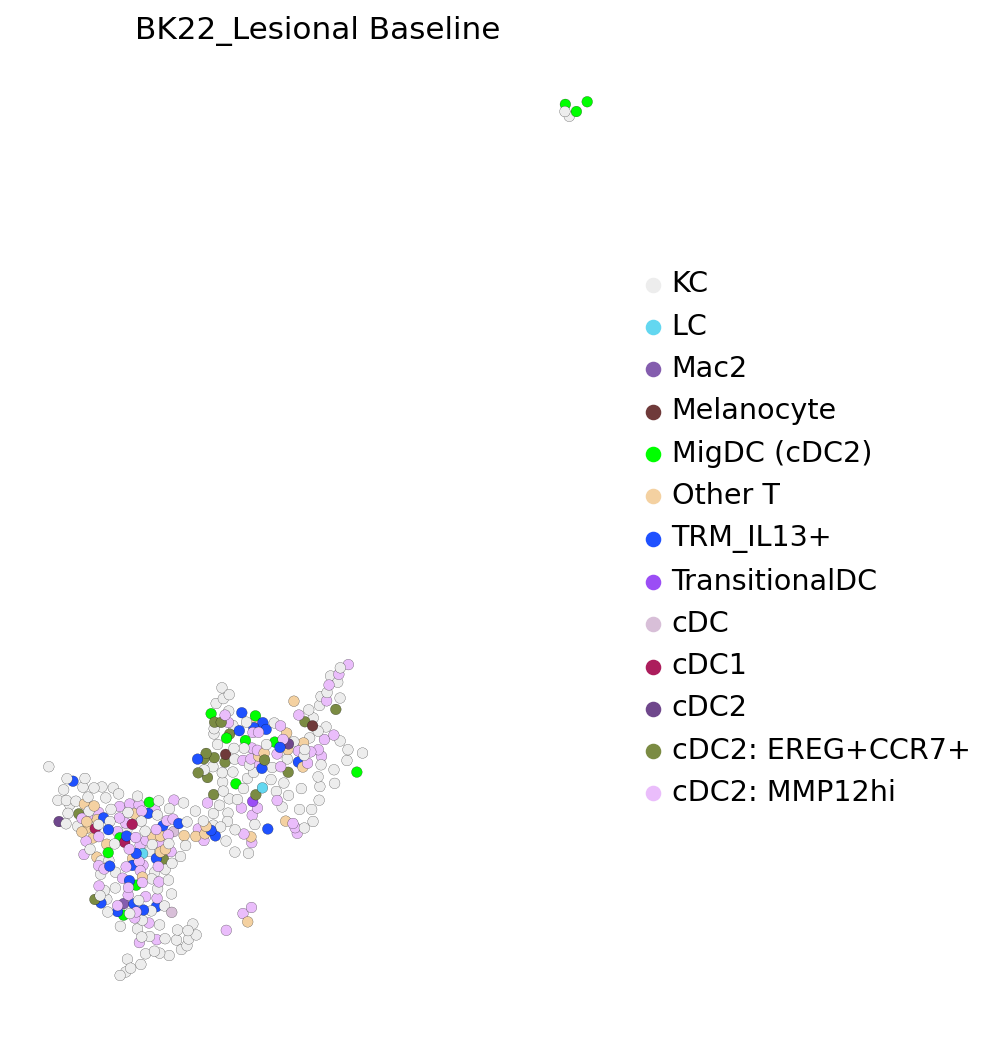

(15, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


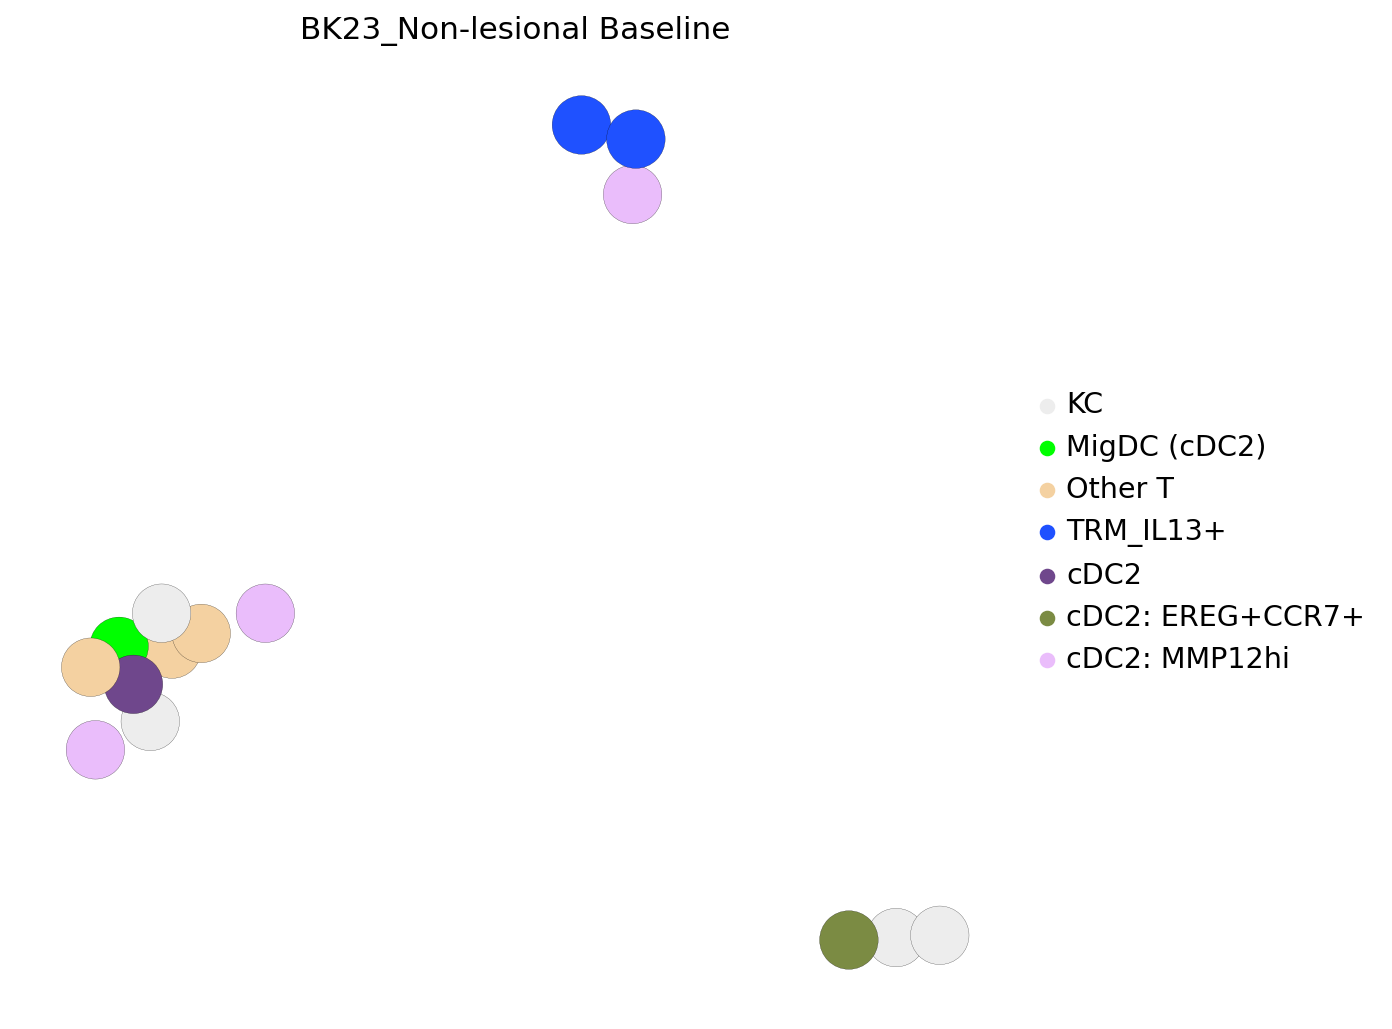

(135, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


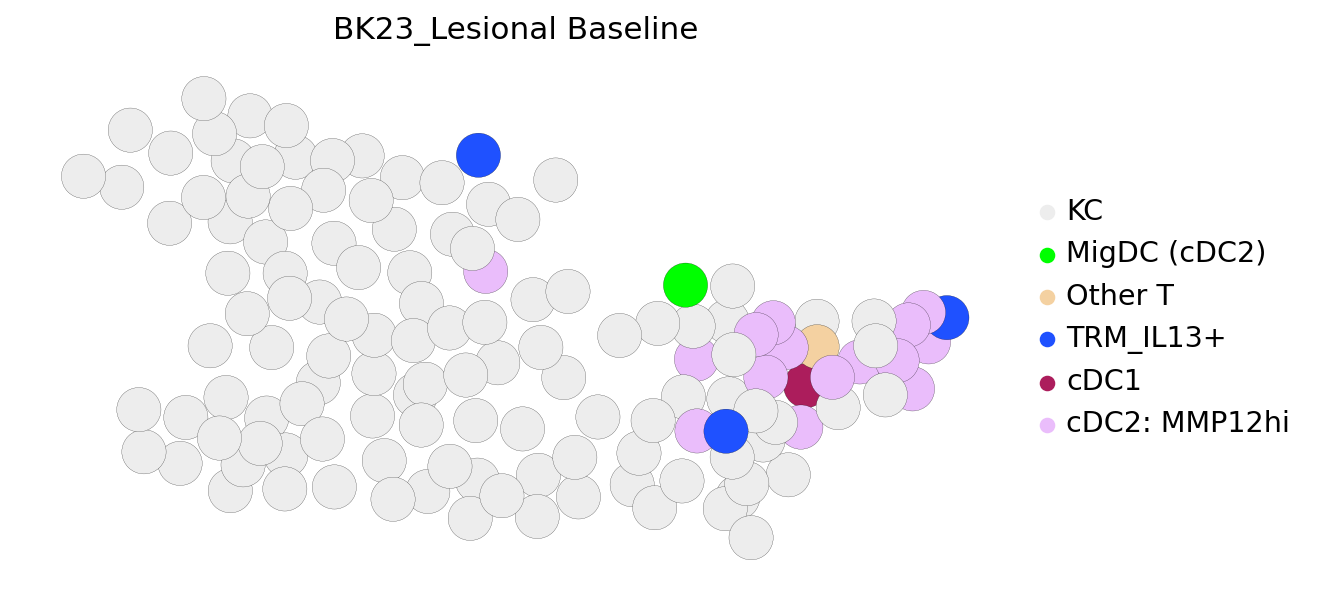

(19, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


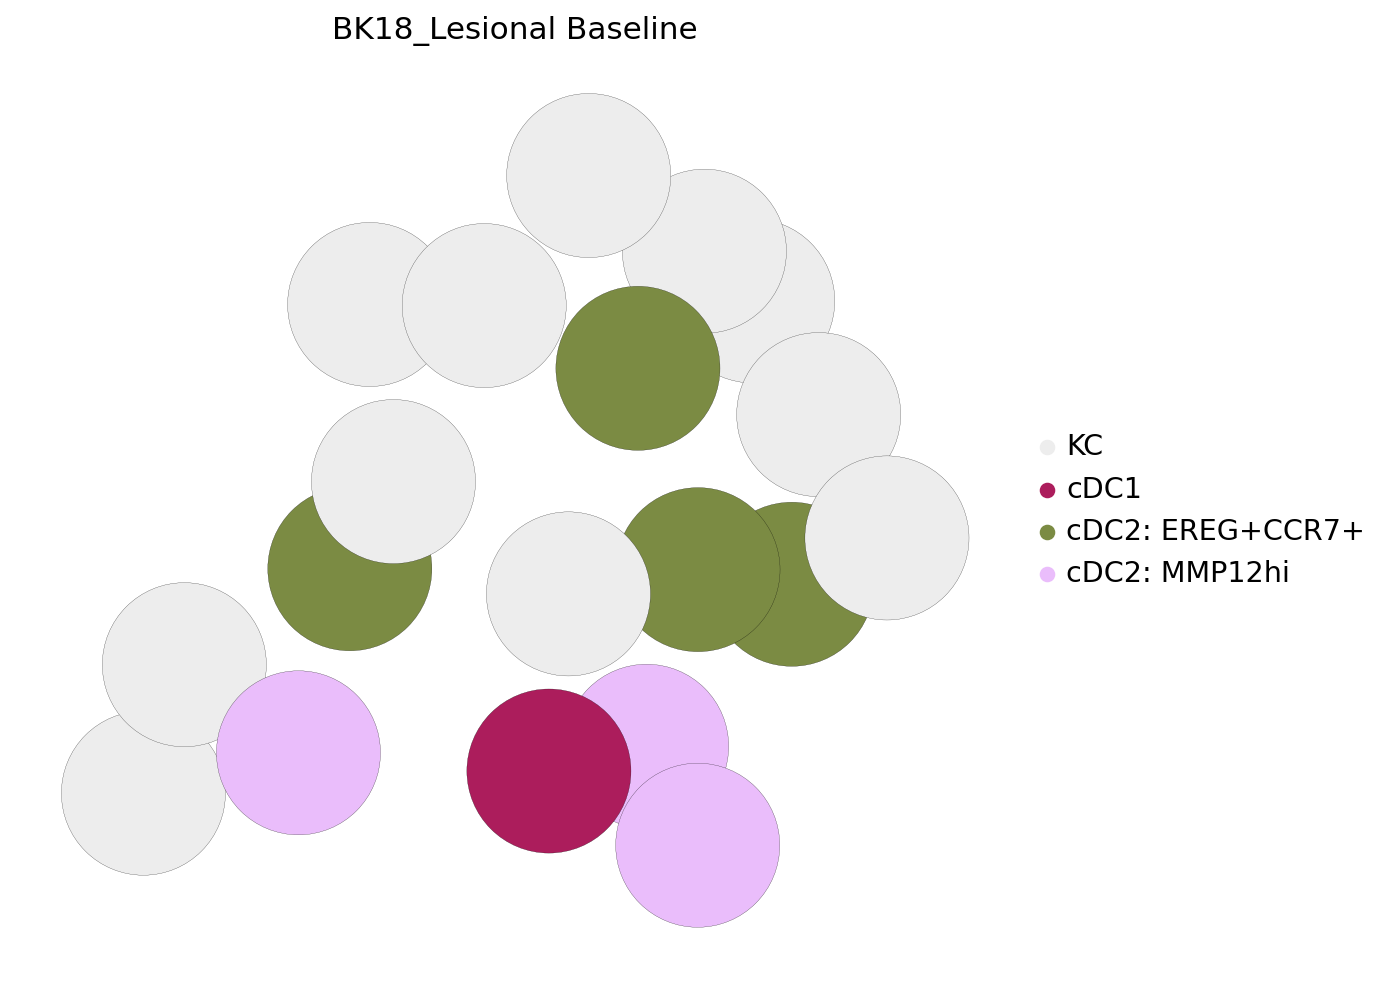

(17, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


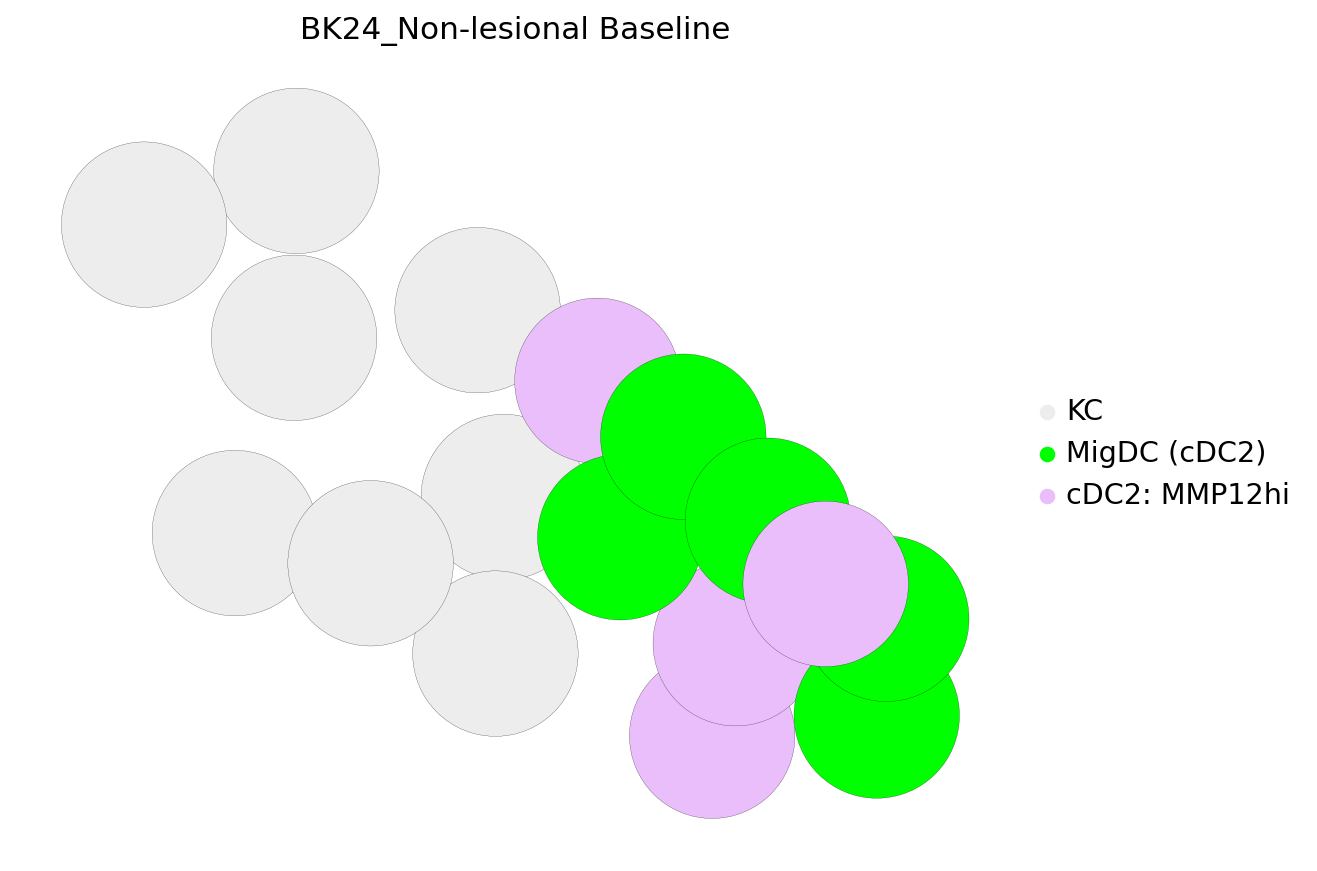

(21, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


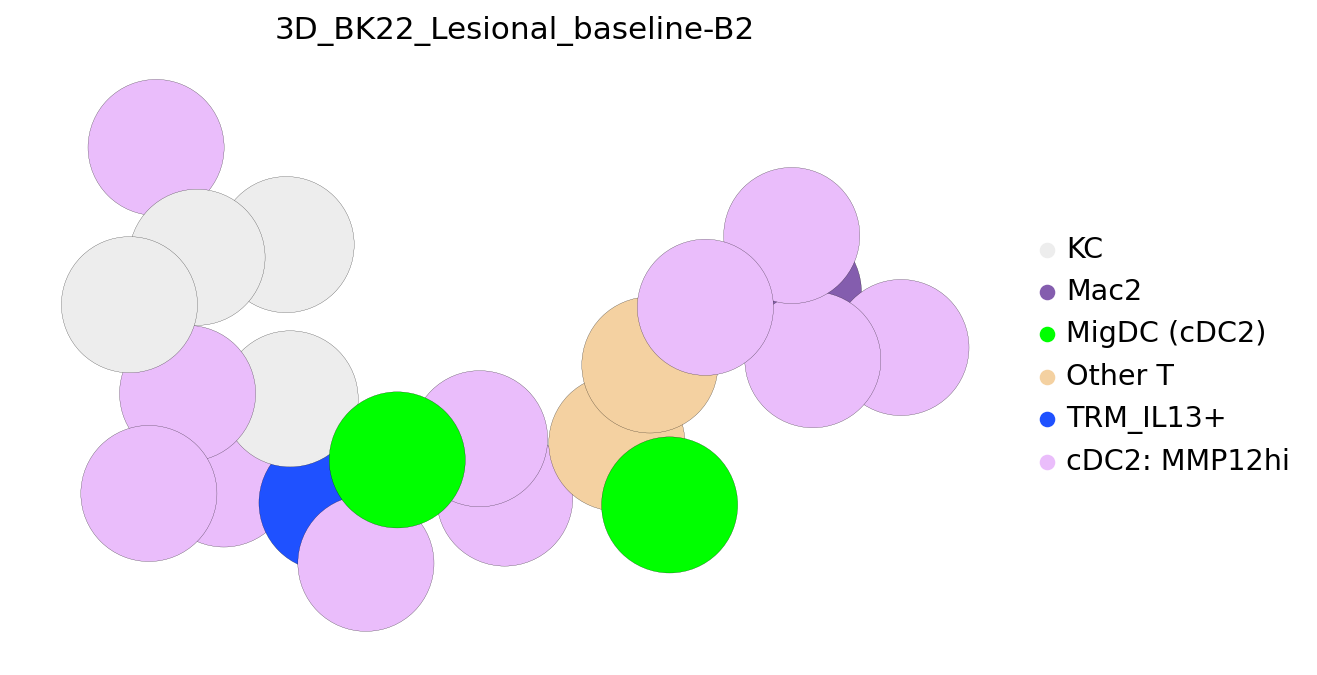

(74, 4993)


/tmp/ipykernel_2057031/3684267766.py:27: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


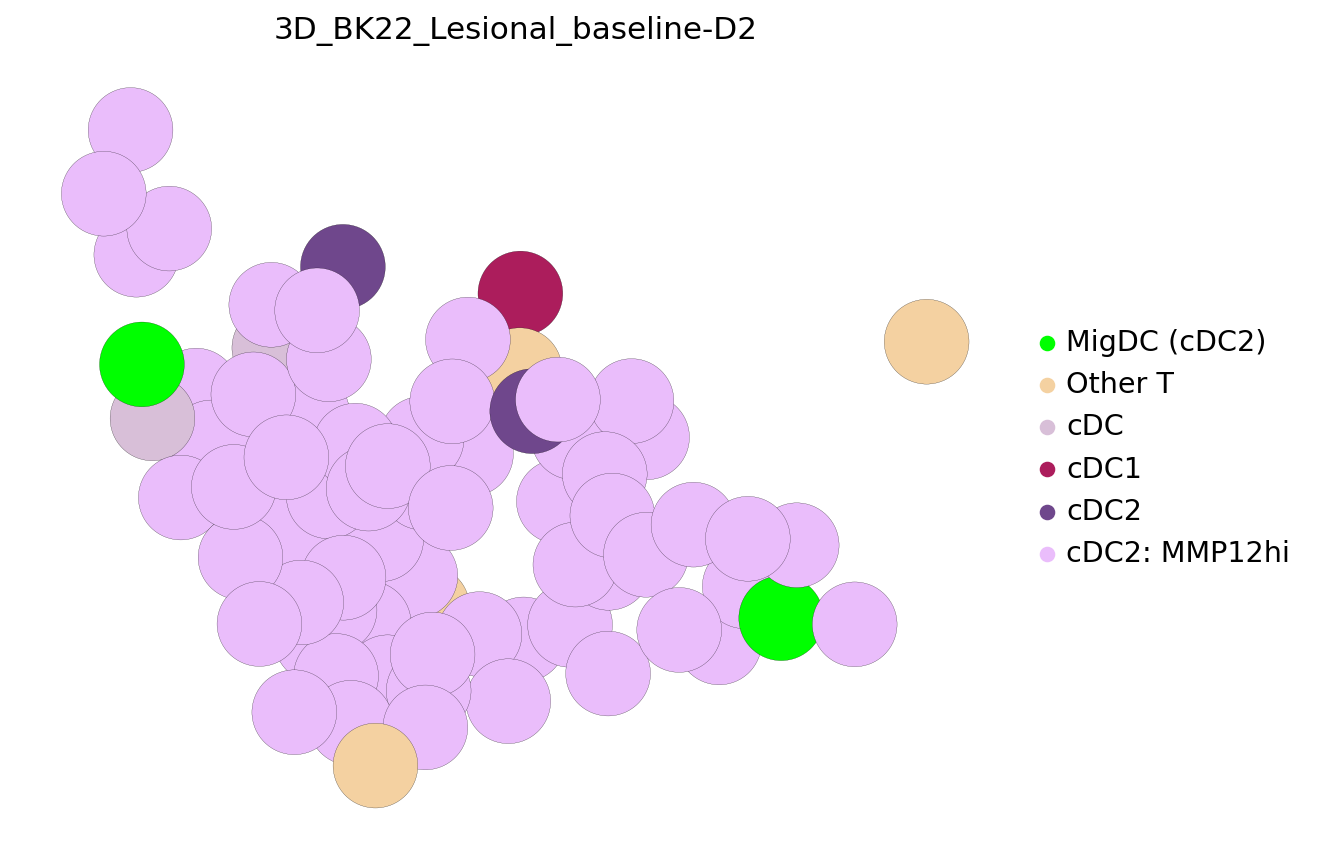

In [21]:
# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------
# KEEP_CT   = [#'KC3',
#     'cDC2: MMP12hi',  'LC',
#    # 'TRM_IL13+', 
#     'MigDC (cDC2)',
#                   'cDC2: EREG+CCR7+',
#     #'KC5', 'KC1', 'Tnaive', 'T', 'Treg',
#                   'cDC1',# 'Treg_LRRC32+', 
#     'cDC2']
import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

with open(file_path, 'rb') as file:
    colors = pickle.load(file)
OTHER_CLR = "#ededed"

for slide_id in SAMPLES :                    # ←  your existing loop
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    # --------------------------------------------------------------
    # 1.  build new annotation column
    # --------------------------------------------------------------
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

#    filt = annos.where(annos.isin(KEEP_CT), "Other")
 #   filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
  #  adata_i.obs["lvl5_filtered"] = filt
   # print(adata_i.shape)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    
    adata_i.obs["lvl5_filtered"] = adata_i.obs["lvl5_annotation"]
    # pd.Categorical(
    #     annos.where(annos.isin(KEEP_CT), "Other"),
    #     categories=KEEP_CT + ["Other"],
    #     ordered=True,
    # )

    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in adata_i.obs["lvl5_filtered"].unique()
    ]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
                            color= "lvl5_filtered",

        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.1,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        palette=colors | {'Other T': '#F4D1A1',
                          "KC": "#ededed" # '#3a4e7a'
                        },
        #legend_loc="None",
                 save=f"SUPP_EPIDERMISAPCHI_{slide_id}.pdf"

        #title=slide_id,
       # legend_loc="right",
    )
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))
#     sc.pl.spatial(
#         adata_i,
#         #library_id="spatial",
#                             color= "lvl5_filtered",

#         spot_size=10 ,
#         #shape=None,
#         edgecolor="black",
#         linewidth=0.1,
#                       #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
#         title=slide_id,
#         legend_loc="None",
#                     save=f"4d_TRM_{slide_id}_BLACKOUTLINE.pdf"

#         #title=slide_id,
#        # legend_loc="right",
#     )

In [22]:
adata_5k_i.obs["lvl5_annotation"].value_counts()

lvl5_annotation
KC                  303
cDC2: MMP12hi       185
Other T              41
TRM_IL13+            35
MigDC (cDC2)         26
cDC2: EREG+CCR7+     23
cDC1                  6
cDC2                  5
cDC                   4
Mac2                  2
LC                    2
Melanocyte            2
TransitionalDC        1
Name: count, dtype: int64

In [23]:
counts = adata_5k_i.obs["lvl5_annotation"].value_counts()
adata_5k_i = adata_5k_i[adata_5k_i.obs["lvl5_annotation"].isin(counts[counts >= 5].index), :]

In [24]:
adata_5k_i.obs["lvl5_annotation"].value_counts().index

Index(['KC', 'cDC2: MMP12hi', 'Other T', 'TRM_IL13+', 'MigDC (cDC2)',
       'cDC2: EREG+CCR7+', 'cDC1', 'cDC2'],
      dtype='object', name='lvl5_annotation')

In [25]:
# CORE_PAPER = ['BK22_Lesional Baseline',
#  'BK23_Lesional Baseline',
#  '3D_BK22_Lesional_baseline-D2',
#  #'BK25_Week 12', 
#                               #'BK21_Week 12' 
#                              ]

(346, 4993)
(346, 4993)


/tmp/ipykernel_2057031/2795455675.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


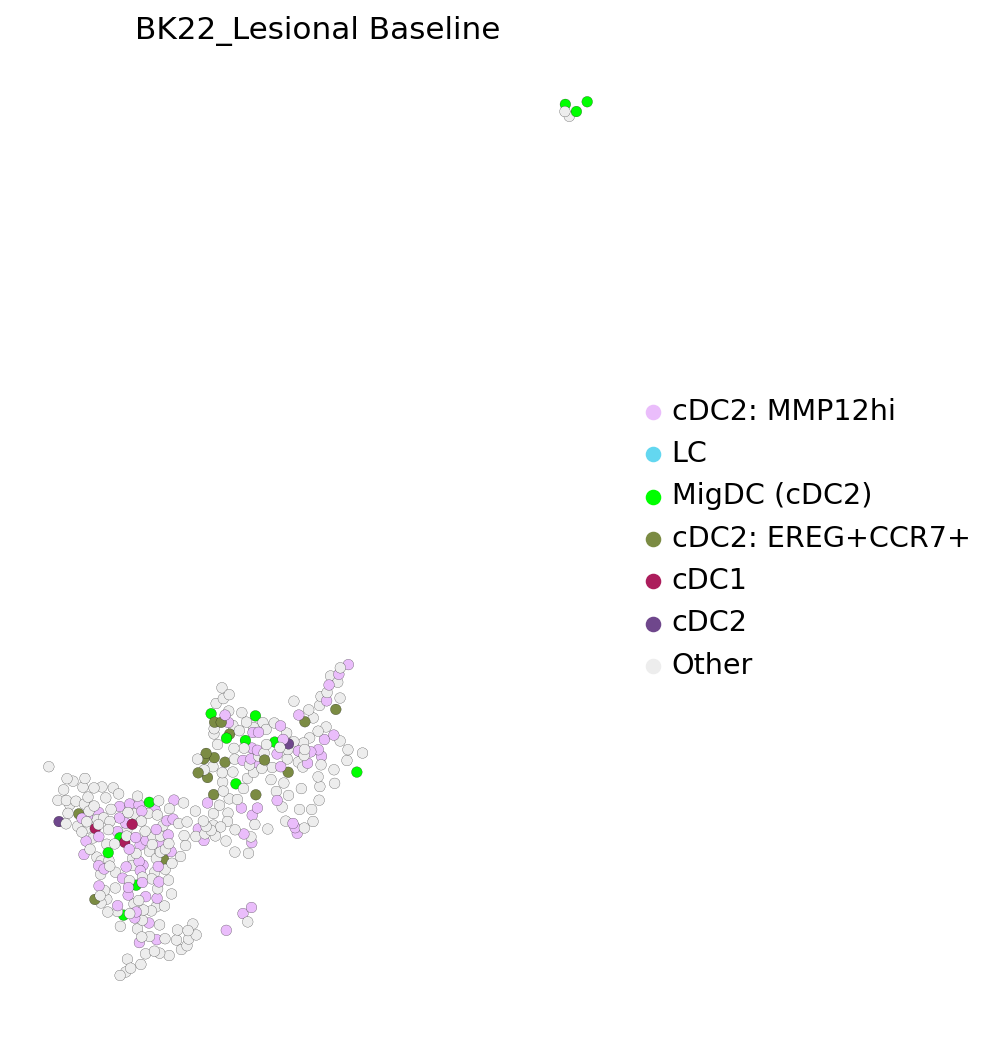

(135, 4993)
(135, 4993)


/tmp/ipykernel_2057031/2795455675.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


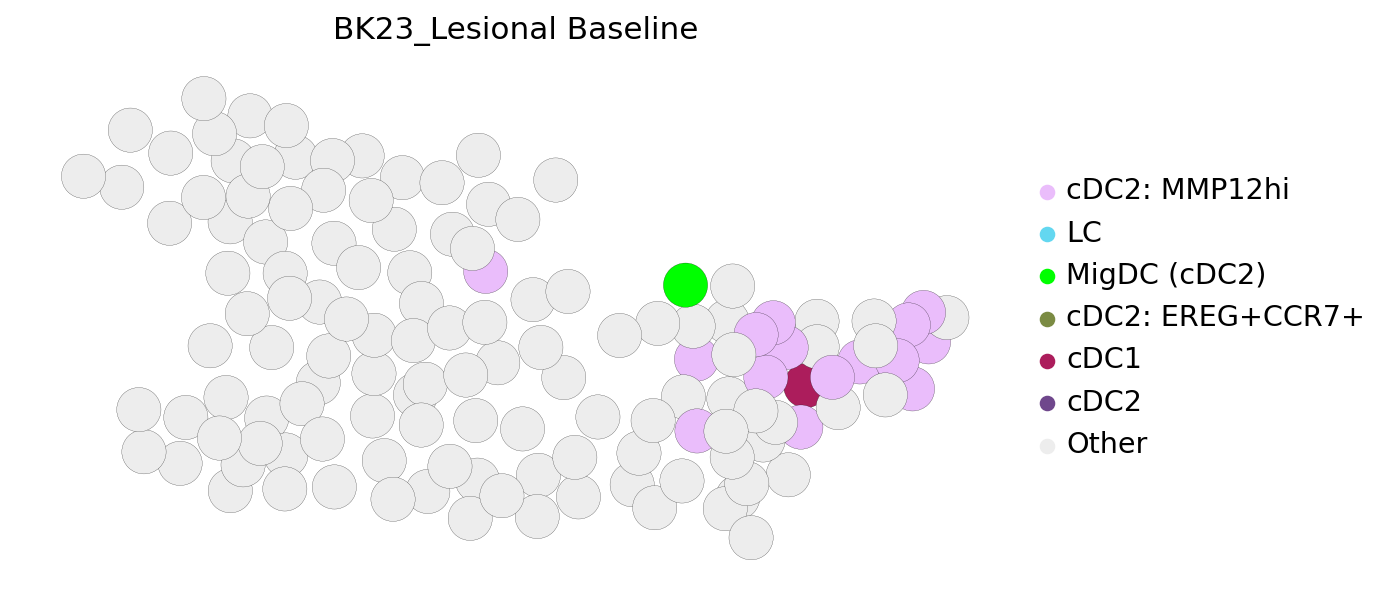

(72, 4993)
(72, 4993)


/tmp/ipykernel_2057031/2795455675.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:


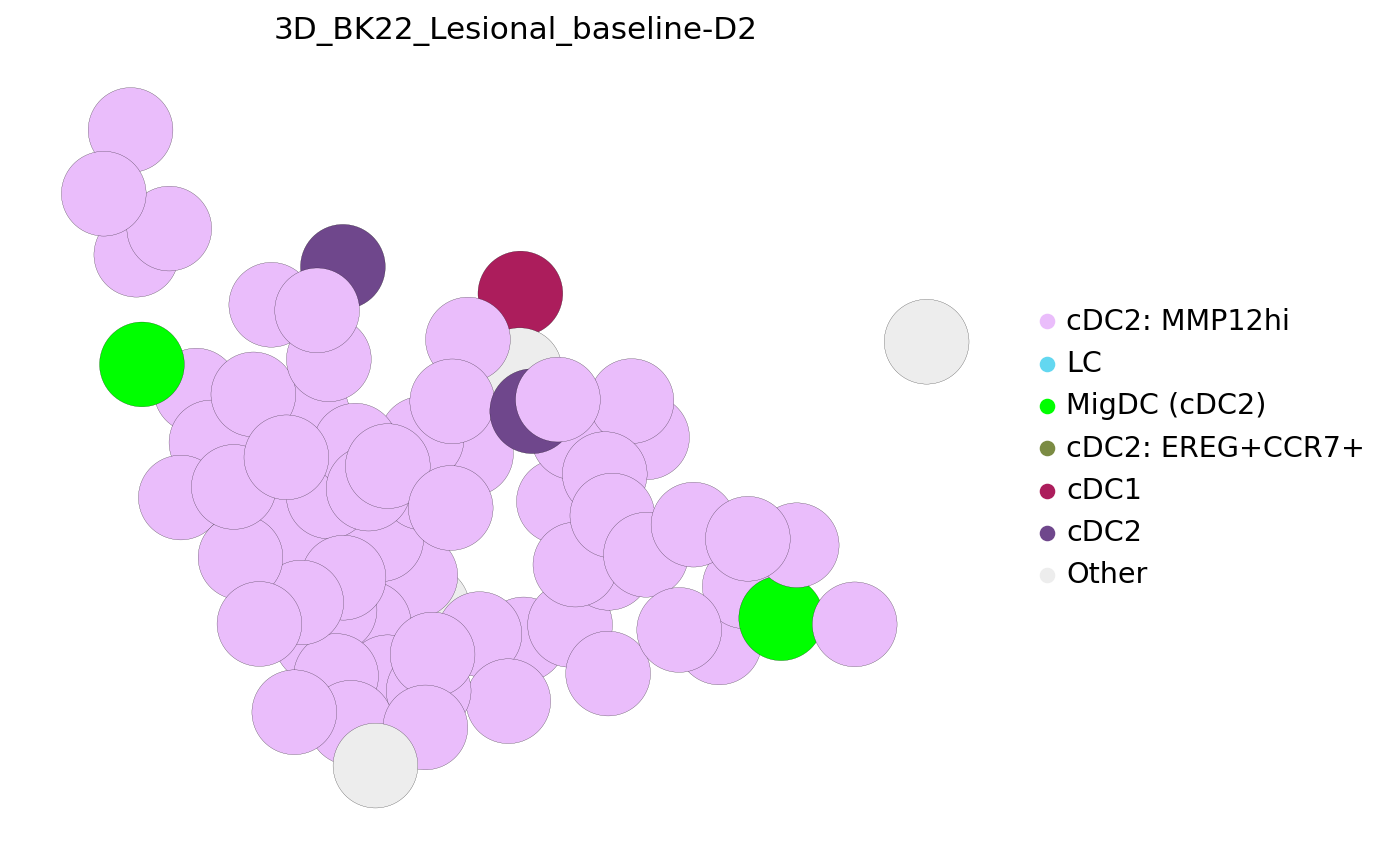

In [26]:
# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------
KEEP_CT   = [#'KC3',
    'cDC2: MMP12hi',  'LC',
   # 'TRM_IL13+', 
    'MigDC (cDC2)',
                  'cDC2: EREG+CCR7+',
    #'KC5', 'KC1', 'Tnaive', 'T', 'Treg',
                  'cDC1',# 'Treg_LRRC32+', 
    'cDC2']
OTHER_CLR = "#ededed"

for slide_id in ['BK22_Lesional Baseline',
 'BK23_Lesional Baseline',
 '3D_BK22_Lesional_baseline-D2',
 #'BK25_Week 12', 
                              #'BK21_Week 12' 
                             ] :                    # ←  your existing loop
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    # --------------------------------------------------------------
    # 1.  build new annotation column
    # --------------------------------------------------------------
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

    filt = annos.where(annos.isin(KEEP_CT), "Other")
    filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
    adata_i.obs["lvl5_filtered"] = filt
    print(adata_i.shape)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    
    adata_i.obs["lvl5_filtered"] = pd.Categorical(
        annos.where(annos.isin(KEEP_CT), "Other"),
        categories=KEEP_CT + ["Other"],
        ordered=True,
    )

    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in KEEP_CT
    ] + [OTHER_CLR]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
                            color= "lvl5_filtered",

        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.1,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        #legend_loc="None",
                  #  save=f"4d_TRM_{slide_id}.pdf"

        #title=slide_id,
       # legend_loc="right",
    )
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))
#     sc.pl.spatial(
#         adata_i,
#         #library_id="spatial",
#                             color= "lvl5_filtered",

#         spot_size=10 ,
#         #shape=None,
#         edgecolor="black",
#         linewidth=0.1,
#                       #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
#         title=slide_id,
#         legend_loc="None",
#                     save=f"4d_TRM_{slide_id}_BLACKOUTLINE.pdf"

#         #title=slide_id,
#        # legend_loc="right",
#     )

# Fig 4a

In [27]:
#sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(30, 30))
sc.settings.set_figure_params(dpi=50, dpi_save=600,facecolor="white", frameon=False, figsize=(40, 40))

# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------

OTHER_CLR = "#F6F6F6"

for i, slide_id in enumerate(CORE_PAPER  ) :                    # ←  your existing loop
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

    filt = annos.where(annos.isin(KEEP_CT), "Other")
    filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
    adata_i.obs["lvl5_filtered"] = filt
    #adata_i.obs["lvl5_filtered"] = [x if x == NICHE else "Other" for x in adata_i.obs["lvl5_filtered"]]

    print(adata_i.shape)
    print(slide_id)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

#     KEEP_CT   = ["ILC1", "TRM_IL17+", "TRM_IL13+", "MigDC"]
#     OTHER_CLR = "#ededed"

#     # 1) build new categorical column
#     annos = adata_i.obs["lvl4_annotation"]
#     adata_i.obs["lvl4_filtered"] = pd.Categorical(
#         annos.where(annos.isin(KEEP_CT), "Other"),
#         categories=KEEP_CT + ["Other"],
#         ordered=True,
#     )

#     # 2) palette: dict, *not* list/colormap
#     palette = {ct: colors.get(ct, OTHER_CLR) for ct in KEEP_CT}
#     palette["Other"] = OTHER_CLR          # add the grey
#         # ← wrap list here
#     # --------------------------------------------------------------
#     # 3.  plot
#     # --------------------------------------------------------------
#     sq.pl.spatial_scatter(
#         adata_i,
#         library_id="spatial",
#         shape=None,
#         color="lvl4_filtered",
#         palette=palette,
#         size=40,
#         vmax=1,
#         edgecolor="black",
#         linewidth=0.1,
#         title=f"{slide_id}",
     
#         legend_loc="right"
#     )
# ------------------------------------------------------------------
    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    adata_i.obs["lvl5_filtered"] = np.where(
        adata_i.obs["niche19"] == NICHE,
        adata_i.obs["lvl5_filtered"],
    "Other"
    )
    adata_i.obs["lvl5_filtered"] = pd.Categorical(
        annos.where(annos.isin(KEEP_CT), "Other"),
        categories=KEEP_CT + ["Other"],
        ordered=True,
    )


    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in KEEP_CT
    ] + [OTHER_CLR]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        color="lvl5_filtered",
        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.09,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        #legend_loc="None",
        legend_fontsize=14,
        legend_loc='None',
        #save=f"4b_celltypes2_{slide_id}.pdf"

 
    )
     
#s.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))
sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(30, 30))


NameError: name 'CORE_PAPER' is not defined

In [ ]:
#sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(30, 30))
sc.settings.set_figure_params(dpi=50, dpi_save=600,facecolor="white", frameon=False, figsize=(40, 40))

# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------

OTHER_CLR = "#F6F6F6"

for i, slide_id in enumerate(CORE_PAPER  ) :                    # ←  your existing loop
    adata_i = adata_5k[adata_5k.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

    filt = annos.where(annos.isin(KEEP_CT), "Other")
    filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
    adata_i.obs["lvl5_filtered"] = filt
    #adata_i.obs["lvl5_filtered"] = [x if x == NICHE else "Other" for x in adata_i.obs["lvl5_filtered"]]

    print(adata_i.shape)
    print(slide_id)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

#     KEEP_CT   = ["ILC1", "TRM_IL17+", "TRM_IL13+", "MigDC"]
#     OTHER_CLR = "#ededed"

#     # 1) build new categorical column
#     annos = adata_i.obs["lvl4_annotation"]
#     adata_i.obs["lvl4_filtered"] = pd.Categorical(
#         annos.where(annos.isin(KEEP_CT), "Other"),
#         categories=KEEP_CT + ["Other"],
#         ordered=True,
#     )

#     # 2) palette: dict, *not* list/colormap
#     palette = {ct: colors.get(ct, OTHER_CLR) for ct in KEEP_CT}
#     palette["Other"] = OTHER_CLR          # add the grey
#         # ← wrap list here
#     # --------------------------------------------------------------
#     # 3.  plot
#     # --------------------------------------------------------------
#     sq.pl.spatial_scatter(
#         adata_i,
#         library_id="spatial",
#         shape=None,
#         color="lvl4_filtered",
#         palette=palette,
#         size=40,
#         vmax=1,
#         edgecolor="black",
#         linewidth=0.1,
#         title=f"{slide_id}",
     
#         legend_loc="right"
#     )
# ------------------------------------------------------------------
    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    adata_i.obs["lvl5_filtered"] = np.where(
        adata_i.obs["niche19"] == NICHE,
        adata_i.obs["lvl5_filtered"],
    "Other"
    )
    adata_i.obs["lvl5_filtered"] = pd.Categorical(
        annos.where(annos.isin(KEEP_CT), "Other"),
        categories=KEEP_CT + ["Other"],
        ordered=True,
    )


    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in KEEP_CT
    ] + [OTHER_CLR]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        color="lvl5_filtered",
        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.09,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        #legend_loc="None",
        legend_fontsize=14,
        legend_loc='None',
        #save=f"4b_celltypes2_{slide_id}.pdf"

 
    )
     
#s.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))
sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(30, 30))


In [ ]:
#sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(30, 30))
sc.settings.set_figure_params(dpi=50, dpi_save=600,facecolor="white", frameon=False, figsize=(40, 40))

# ------------------------------------------------------------------
# 0.  cell types to keep
# ------------------------------------------------------------------

OTHER_CLR = "#F6F6F6"

for i, slide_id in enumerate(CORE_PAPER  ) :                    # ←  your existing loop
    adata_i = adata_5k_i[adata_5k_i.obs["info_id6"] == slide_id].copy()
    print(adata_i.shape)
    annos = adata_i.obs["lvl5_annotation"]
    if pd.api.types.is_categorical_dtype(annos) and "Other" not in annos.cat.categories:
        annos = annos.cat.add_categories(["Other"])

    filt = annos.where(annos.isin(KEEP_CT), "Other")
    filt  = pd.Categorical(filt, categories=KEEP_CT + ["Other"], ordered=True)
    adata_i.obs["lvl5_filtered"] = filt
    #adata_i.obs["lvl5_filtered"] = [x if x == NICHE else "Other" for x in adata_i.obs["lvl5_filtered"]]

    print(adata_i.shape)
    print(slide_id)

    # --------------------------------------------------------------
    # 2.  colour palette in same order
    # --------------------------------------------------------------
#     from matplotlib.colors import ListedColormap

#     from matplotlib.colors import to_hex

#     KEEP_CT   = ["ILC1", "TRM_IL17+", "TRM_IL13+", "MigDC"]
#     OTHER_CLR = "#ededed"

#     # 1) build new categorical column
#     annos = adata_i.obs["lvl4_annotation"]
#     adata_i.obs["lvl4_filtered"] = pd.Categorical(
#         annos.where(annos.isin(KEEP_CT), "Other"),
#         categories=KEEP_CT + ["Other"],
#         ordered=True,
#     )

#     # 2) palette: dict, *not* list/colormap
#     palette = {ct: colors.get(ct, OTHER_CLR) for ct in KEEP_CT}
#     palette["Other"] = OTHER_CLR          # add the grey
#         # ← wrap list here
#     # --------------------------------------------------------------
#     # 3.  plot
#     # --------------------------------------------------------------
#     sq.pl.spatial_scatter(
#         adata_i,
#         library_id="spatial",
#         shape=None,
#         color="lvl4_filtered",
#         palette=palette,
#         size=40,
#         vmax=1,
#         edgecolor="black",
#         linewidth=0.1,
#         title=f"{slide_id}",
     
#         legend_loc="right"
#     )
# ------------------------------------------------------------------
    
    adata_i.obs["lvl5_annotation"]=adata_i.obs["lvl5_annotation"].astype(str)
    annos = adata_i.obs["lvl5_annotation"]
    adata_i.obs["lvl5_filtered"] = np.where(
        adata_i.obs["niche19"] == NICHE,
        adata_i.obs["lvl5_filtered"],
    "Other"
    )
    adata_i.obs["lvl5_filtered"] = pd.Categorical(
        annos.where(annos.isin(KEEP_CT), "Other"),
        categories=KEEP_CT + ["Other"],
        ordered=True,
    )


    # ------------------------------------------------------------------
    # 2.  store colour list in `.uns`
    #     order MUST match the category order above
    # ------------------------------------------------------------------
    adata_i.uns["lvl5_filtered_colors"] = [
        colors.get(ct, OTHER_CLR) for ct in KEEP_CT
    ] + [OTHER_CLR]

    # ------------------------------------------------------------------
    # 3.  plot — no `palette=` argument needed
    # ------------------------------------------------------------------
    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        color="lvl5_filtered",
        spot_size=12 ,
        #shape=None,
        edgecolor="black",
        linewidth=0.09,
                      #  save=f"sebimmune_celltypes_{DONOR_ID}.pdf",
        title=slide_id,
        #legend_loc="None",
        legend_fontsize=14,
        #legend_loc='None',
        #save=f"4b_celltypes2_{slide_id}.pdf"

 
    )
     
#s.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))
sc.settings.set_figure_params(dpi=50,dpi_save=300, facecolor="white", frameon=False, figsize=(30, 30))
